# NEWSLETTER

### Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### Load Raw Data

In [2]:
# Load the raw data
raw_data_path = '../data/fathom_newsletter_site.csv'

# Check if file exists
if not os.path.exists(raw_data_path):
    print(f"❌ Error: File not found at {raw_data_path}")
    print("Please make sure the file exists in the data folder.")
else:
    # Read the CSV file
    df_raw = pd.read_csv(raw_data_path)
    
    print("✓ Raw data loaded successfully")
    print(f"\nDataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
    print(f"\nFirst few rows:")
    display(df_raw.head(5))

✓ Raw data loaded successfully

Dataset shape: 4198 rows × 5 columns

First few rows:


,Timestamp,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025-11-06 21:00:00,125,107,77.13,0.88
1,2025-11-29 18:00:00,213,178,203.14,0.85
2,2025-10-19 14:00:00,155,148,54.50,0.96
3,2025-11-06 17:00:00,179,148,230.25,0.91
4,2025-07-16 22:00:00,97,83,154.57,0.86


### Inspect Data Structure

In [3]:
# Display data info
print("Data Information:")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("Missing Values Check:")
print("=" * 60)
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

print("\n" + "=" * 60)
print("Basic Statistics:")
print("=" * 60)
display(df_raw.describe())

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4198 entries, 0 to 4197
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     4198 non-null   object 
 1   Pageviews     4198 non-null   int64  
 2   Visits        4198 non-null   int64  
 3   Avg Duration  4124 non-null   float64
 4   Bounce Rate   4198 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 164.1+ KB

Missing Values Check:
Avg Duration    74
dtype: int64

Basic Statistics:


,Pageviews,Visits,Avg Duration,Bounce Rate
count,4198.00,4198.00,4124.00,4198.00
mean,126.95,111.60,124.96,0.91
std,94.56,73.79,105.21,0.04
min,3.00,3.00,2.00,0.49
25%,70.00,63.00,56.41,0.89
50%,109.00,98.00,96.19,0.91
75%,157.00,141.00,163.36,0.93
max,1850.00,563.00,1630.00,1.00


### Process Timestamp Column

In [4]:
# Create a working copy of the data
df = df_raw.copy()

# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract just the date (remove time component)
df['Date'] = df['Timestamp'].dt.date

print("✓ Timestamp processed successfully")
print(f"\nDate range in dataset:")
print(f"  Earliest: {df['Date'].min()}")
print(f"  Latest: {df['Date'].max()}")
print(f"  Total days: {(df['Date'].max() - df['Date'].min()).days + 1} days")

print(f"\nSample of processed data:")
display(df[['Timestamp', 'Date', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']].head(5))

✓ Timestamp processed successfully

Date range in dataset:
  Earliest: 2025-06-16
  Latest: 2025-12-08
  Total days: 176 days

Sample of processed data:


,Timestamp,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025-11-06 21:00:00,2025-11-06,125,107,77.13,0.88
1,2025-11-29 18:00:00,2025-11-29,213,178,203.14,0.85
2,2025-10-19 14:00:00,2025-10-19,155,148,54.50,0.96
3,2025-11-06 17:00:00,2025-11-06,179,148,230.25,0.91
4,2025-07-16 22:00:00,2025-07-16,97,83,154.57,0.86


### Create Daily Aggregated Data

In [5]:
# Group by date and aggregate
df_daily = df.groupby('Date').agg({
    'Pageviews': 'sum',           # Sum all pageviews for the day
    'Visits': 'sum',              # Sum all visits for the day
    'Avg Duration': 'mean',       # Average duration across all hours
    'Bounce Rate': 'mean'         # Average bounce rate across all hours
}).reset_index()

# Convert Date back to datetime for easier manipulation
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

# Format the Date column as MM/DD/YYYY
df_daily['Date'] = df_daily['Date'].dt.strftime('%m/%d/%Y')

# Round numeric values for cleaner presentation
df_daily['Avg Duration'] = df_daily['Avg Duration'].round(2)
df_daily['Bounce Rate'] = (df_daily['Bounce Rate'] * 100).round(2)  # Convert to percentage

# Rename columns to match desired output
df_daily.columns = ['Date', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']

# Add percentage sign to Bounce Rate
df_daily['Bounce Rate'] = df_daily['Bounce Rate'].astype(str) + '%'

print("✓ Daily data aggregated successfully")
print(f"\nDaily dataset shape: {df_daily.shape[0]} rows × {df_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_daily.head(5))

print(f"\nLast 5 days:")
display(df_daily.tail(5))

✓ Daily data aggregated successfully

Daily dataset shape: 176 rows × 5 columns

First 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,06/16/2025,1223,1109,135.27,91.1%
1,06/17/2025,3423,3119,86.93,91.97%
2,06/18/2025,3126,2819,120.12,91.21%
3,06/19/2025,2699,2432,115.62,91.22%
4,06/20/2025,1646,1476,78.01,89.96%



Last 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
171,12/04/2025,6497,5864,112.85,91.84%
172,12/05/2025,6761,6114,127.04,92.65%
173,12/06/2025,6826,6131,138.86,91.79%
174,12/07/2025,7004,6292,130.39,91.64%
175,12/08/2025,4247,3830,138.26,91.69%


### Create Weekly Aggregated Data

In [6]:
# Work with original data with datetime
df_weekly_prep = df.copy()
df_weekly_prep['Date'] = pd.to_datetime(df_weekly_prep['Date'])

# Create week identifier (week starting on Sunday)
df_weekly_prep['Week'] = df_weekly_prep['Date'] - pd.to_timedelta(
    (df_weekly_prep['Date'].dt.dayofweek + 1) % 7,
    unit='D'
)

# Aggregate by week
df_weekly = df_weekly_prep.groupby('Week').agg({
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean'
}).reset_index()

# Add week start and end
df_weekly['Week_Start'] = df_weekly['Week']
df_weekly['Week_End'] = df_weekly['Week'] + pd.Timedelta(days=6)

# Create week number
df_weekly['Week_Num'] = range(1, len(df_weekly) + 1)

# Format date range
df_weekly['Date Range'] = (
    df_weekly['Week_Start'].dt.strftime('%m/%d/%Y') + ' - ' +
    df_weekly['Week_End'].dt.strftime('%m/%d/%Y')
)

# Round numeric values
df_weekly['Avg Duration'] = df_weekly['Avg Duration'].round(2)
df_weekly['Bounce Rate'] = (df_weekly['Bounce Rate'] * 100).round(2)

# Select and reorder columns
df_weekly = df_weekly[['Week_Num', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']]

# Rename columns
df_weekly.columns = ['Week', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']

# Add percentage sign to Bounce Rate
df_weekly['Bounce Rate'] = df_weekly['Bounce Rate'].astype(str) + '%'

print("✓ Weekly data aggregated successfully")
print(f"\nWeekly dataset shape: {df_weekly.shape[0]} rows × {df_weekly.shape[1]} columns")
print(f"\nFirst 5 weeks:")
display(df_weekly.head(5))

print(f"\nLast 5 weeks:")
display(df_weekly.tail(5))

✓ Weekly data aggregated successfully

Weekly dataset shape: 26 rows × 6 columns

First 5 weeks:


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,1,06/15/2025 - 06/21/2025,12632,11411,100.25,91.14%
1,2,06/22/2025 - 06/28/2025,13035,11645,133.83,90.72%
2,3,06/29/2025 - 07/05/2025,17453,15418,89.84,89.33%
3,4,07/06/2025 - 07/12/2025,18297,16421,100.45,90.04%
4,5,07/13/2025 - 07/19/2025,11413,10231,119.79,90.71%



Last 5 weeks:


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
21,22,11/09/2025 - 11/15/2025,39969,35519,108.79,90.77%
22,23,11/16/2025 - 11/22/2025,38613,34273,119.98,91.08%
23,24,11/23/2025 - 11/29/2025,37895,33821,143.11,91.69%
24,25,11/30/2025 - 12/06/2025,42385,37997,127.09,91.72%
25,26,12/07/2025 - 12/13/2025,11251,10122,133.42,91.66%


### Create Monthly Aggregated Data

In [7]:
# Work with original data with datetime
df_monthly_prep = df.copy()
df_monthly_prep['Date'] = pd.to_datetime(df_monthly_prep['Date'])

# Extract year and month
df_monthly_prep['Year'] = df_monthly_prep['Date'].dt.year
df_monthly_prep['Month_Num'] = df_monthly_prep['Date'].dt.month
df_monthly_prep['Month_Name'] = df_monthly_prep['Date'].dt.strftime('%B')  # Full month name

# Create month identifier for grouping
df_monthly_prep['YearMonth'] = df_monthly_prep['Date'].dt.to_period('M')

# Aggregate by month
df_monthly = df_monthly_prep.groupby('YearMonth').agg({
    'Date': ['min', 'max'],
    'Month_Name': 'first',
    'Year': 'first',
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean'
}).reset_index()

# Flatten column names
df_monthly.columns = ['YearMonth', 'Month_Start', 'Month_End', 'Month_Name', 'Year', 
                      'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']

# Create Month label (e.g., "January 2025")
df_monthly['Month'] = df_monthly['Month_Name'] + ' ' + df_monthly['Year'].astype(str)

# Create Date Range
df_monthly['Date Range'] = (df_monthly['Month_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                            df_monthly['Month_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_monthly['Avg Duration'] = df_monthly['Avg Duration'].round(2)
df_monthly['Bounce Rate'] = (df_monthly['Bounce Rate'] * 100).round(2)

# Select and reorder columns
df_monthly = df_monthly[['Month', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']]

# Add percentage sign to Bounce Rate
df_monthly['Bounce Rate'] = df_monthly['Bounce Rate'].astype(str) + '%'

print("✓ Monthly data aggregated successfully")
print(f"\nMonthly dataset shape: {df_monthly.shape[0]} rows × {df_monthly.shape[1]} columns")
print(f"\nAll months:")
display(df_monthly)

✓ Monthly data aggregated successfully

Monthly dataset shape: 7 rows × 6 columns

All months:


,Month,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,June 2025,06/16/2025 - 06/30/2025,28428,25495,118.04,90.73%
1,July 2025,07/01/2025 - 07/31/2025,72697,64563,106.06,90.49%
2,August 2025,08/01/2025 - 08/31/2025,75237,65999,115.79,90.7%
3,September 2025,09/01/2025 - 09/30/2025,80935,71012,125.36,90.88%
4,October 2025,10/01/2025 - 10/31/2025,80549,68327,150.92,91.05%
5,November 2025,11/01/2025 - 11/30/2025,147147,130054,129.72,90.81%
6,December 2025,12/01/2025 - 12/08/2025,47932,43051,122.96,91.78%


### Create Quarterly Aggregated Data

In [8]:
# Work with original data with datetime
df_quarterly_prep = df.copy()
df_quarterly_prep['Date'] = pd.to_datetime(df_quarterly_prep['Date'])

# Extract year and quarter
df_quarterly_prep['Year'] = df_quarterly_prep['Date'].dt.year
df_quarterly_prep['Quarter_Num'] = df_quarterly_prep['Date'].dt.quarter

# Create quarter identifier for grouping
df_quarterly_prep['YearQuarter'] = (df_quarterly_prep['Year'].astype(str) + 'Q' + 
                                    df_quarterly_prep['Quarter_Num'].astype(str))

# Aggregate by quarter
df_quarterly = df_quarterly_prep.groupby('YearQuarter').agg({
    'Date': ['min', 'max'],
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean'
}).reset_index()

# Flatten column names
df_quarterly.columns = ['Quarter', 'Quarter_Start', 'Quarter_End', 'Pageviews', 'Visits', 
                        'Avg Duration', 'Bounce Rate']

# Create Date Range
df_quarterly['Date Range'] = (df_quarterly['Quarter_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                              df_quarterly['Quarter_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_quarterly['Avg Duration'] = df_quarterly['Avg Duration'].round(2)
df_quarterly['Bounce Rate'] = (df_quarterly['Bounce Rate'] * 100).round(2)

# Select and reorder columns
df_quarterly = df_quarterly[['Quarter', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']]

# Add percentage sign to Bounce Rate
df_quarterly['Bounce Rate'] = df_quarterly['Bounce Rate'].astype(str) + '%'

print("✓ Quarterly data aggregated successfully")
print(f"\nQuarterly dataset shape: {df_quarterly.shape[0]} rows × {df_quarterly.shape[1]} columns")
print(f"\nAll quarters:")
display(df_quarterly)

✓ Quarterly data aggregated successfully

Quarterly dataset shape: 3 rows × 6 columns

All quarters:


,Quarter,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025Q2,06/16/2025 - 06/30/2025,28428,25495,118.04,90.73%
1,2025Q3,07/01/2025 - 09/30/2025,228869,201574,115.71,90.69%
2,2025Q4,10/01/2025 - 12/08/2025,275628,241432,138.50,91.03%


### Create Annual Aggregated Data

In [9]:
# Work with original data with datetime
df_annual_prep = df.copy()
df_annual_prep['Date'] = pd.to_datetime(df_annual_prep['Date'])

# Extract year
df_annual_prep['Year'] = df_annual_prep['Date'].dt.year

# Aggregate by year
df_annual = df_annual_prep.groupby('Year').agg({
    'Date': ['min', 'max'],
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean'
}).reset_index()

# Flatten column names
df_annual.columns = ['Year', 'Year_Start', 'Year_End', 'Pageviews', 'Visits', 
                     'Avg Duration', 'Bounce Rate']

# Create Date Range
df_annual['Date Range'] = (df_annual['Year_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                           df_annual['Year_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_annual['Avg Duration'] = df_annual['Avg Duration'].round(2)
df_annual['Bounce Rate'] = (df_annual['Bounce Rate'] * 100).round(2)

# Select and reorder columns
df_annual = df_annual[['Year', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']]

# Add percentage sign to Bounce Rate
df_annual['Bounce Rate'] = df_annual['Bounce Rate'].astype(str) + '%'

print("✓ Annual data aggregated successfully")
print(f"\nAnnual dataset shape: {df_annual.shape[0]} rows × {df_annual.shape[1]} columns")
print(f"\nAll years:")
display(df_annual)

✓ Annual data aggregated successfully

Annual dataset shape: 1 rows × 6 columns

All years:


,Year,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025,06/16/2025 - 12/08/2025,532925,468501,124.96,90.82%


### Create Output Directory

In [10]:
# Define output directory path
output_dir = '../outputs/newsletter'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Verify directory was created
if os.path.exists(output_dir):
    print(f"✓ Output directory created successfully: {output_dir}")
else:
    print(f"❌ Failed to create directory: {output_dir}")

✓ Output directory created successfully: ../outputs/newsletter


### Save All Datasets to CSV

In [11]:
# Save Daily data
daily_path = os.path.join(output_dir, 'daily_newsletter.csv')
df_daily.to_csv(daily_path, index=False)
print(f"✓ Saved: {daily_path}")
print(f"  Shape: {df_daily.shape[0]} rows × {df_daily.shape[1]} columns\n")

# Save Weekly data
weekly_path = os.path.join(output_dir, 'weekly_newsletter.csv')
df_weekly.to_csv(weekly_path, index=False)
print(f"✓ Saved: {weekly_path}")
print(f"  Shape: {df_weekly.shape[0]} rows × {df_weekly.shape[1]} columns\n")

# Save Monthly data
monthly_path = os.path.join(output_dir, 'monthly_newsletter.csv')
df_monthly.to_csv(monthly_path, index=False)
print(f"✓ Saved: {monthly_path}")
print(f"  Shape: {df_monthly.shape[0]} rows × {df_monthly.shape[1]} columns\n")

# Save Quarterly data
quarterly_path = os.path.join(output_dir, 'quarterly_newsletter.csv')
df_quarterly.to_csv(quarterly_path, index=False)
print(f"✓ Saved: {quarterly_path}")
print(f"  Shape: {df_quarterly.shape[0]} rows × {df_quarterly.shape[1]} columns\n")

# Save Annual data
annual_path = os.path.join(output_dir, 'annual_newsletter.csv')
df_annual.to_csv(annual_path, index=False)
print(f"✓ Saved: {annual_path}")
print(f"  Shape: {df_annual.shape[0]} rows × {df_annual.shape[1]} columns\n")

print("=" * 60)
print("✓ All datasets saved successfully!")
print("=" * 60)

✓ Saved: ../outputs/newsletter/daily_newsletter.csv
  Shape: 176 rows × 5 columns

✓ Saved: ../outputs/newsletter/weekly_newsletter.csv
  Shape: 26 rows × 6 columns

✓ Saved: ../outputs/newsletter/monthly_newsletter.csv
  Shape: 7 rows × 6 columns

✓ Saved: ../outputs/newsletter/quarterly_newsletter.csv
  Shape: 3 rows × 6 columns

✓ Saved: ../outputs/newsletter/annual_newsletter.csv
  Shape: 1 rows × 6 columns

✓ All datasets saved successfully!


### Verification - Preview Saved Files

In [12]:
# List all files in the output directory
print("Files in output directory:")
print("=" * 60)
for file in os.listdir(output_dir):
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024  # Size in KB
    print(f"  • {file:<30} ({file_size:.2f} KB)")

print("\n" + "=" * 60)
print("Preview of Daily Newsletter (first 5 rows):")
print("=" * 60)
df_verify_daily = pd.read_csv(daily_path)
display(df_verify_daily.head())

print("\n" + "=" * 60)
print("Preview of Weekly Newsletter (first 5 rows):")
print("=" * 60)
df_verify_weekly = pd.read_csv(weekly_path)
display(df_verify_weekly.head())

print("\n" + "=" * 60)
print("Preview of Monthly Newsletter (all rows):")
print("=" * 60)
df_verify_monthly = pd.read_csv(monthly_path)
display(df_verify_monthly)

print("\n" + "=" * 60)
print("Preview of Quarterly Newsletter (all rows):")
print("=" * 60)
df_verify_quarterly = pd.read_csv(quarterly_path)
display(df_verify_quarterly)

print("\n" + "=" * 60)
print("Preview of Annual Newsletter (all rows):")
print("=" * 60)
df_verify_annual = pd.read_csv(annual_path)
display(df_verify_annual)

Files in output directory:
  • daily_newsletter.csv           (5.98 KB)
  • annual_newsletter.csv          (0.11 KB)
  • monthly_newsletter.csv         (0.49 KB)
  • quarterly_newsletter.csv       (0.23 KB)
  • weekly_newsletter.csv          (1.39 KB)
  • custom_newsletter.csv          (0.15 KB)

Preview of Daily Newsletter (first 5 rows):


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,06/16/2025,1223,1109,135.27,91.1%
1,06/17/2025,3423,3119,86.93,91.97%
2,06/18/2025,3126,2819,120.12,91.21%
3,06/19/2025,2699,2432,115.62,91.22%
4,06/20/2025,1646,1476,78.01,89.96%



Preview of Weekly Newsletter (first 5 rows):


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,1,06/15/2025 - 06/21/2025,12632,11411,100.25,91.14%
1,2,06/22/2025 - 06/28/2025,13035,11645,133.83,90.72%
2,3,06/29/2025 - 07/05/2025,17453,15418,89.84,89.33%
3,4,07/06/2025 - 07/12/2025,18297,16421,100.45,90.04%
4,5,07/13/2025 - 07/19/2025,11413,10231,119.79,90.71%



Preview of Monthly Newsletter (all rows):


,Month,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,June 2025,06/16/2025 - 06/30/2025,28428,25495,118.04,90.73%
1,July 2025,07/01/2025 - 07/31/2025,72697,64563,106.06,90.49%
2,August 2025,08/01/2025 - 08/31/2025,75237,65999,115.79,90.7%
3,September 2025,09/01/2025 - 09/30/2025,80935,71012,125.36,90.88%
4,October 2025,10/01/2025 - 10/31/2025,80549,68327,150.92,91.05%
5,November 2025,11/01/2025 - 11/30/2025,147147,130054,129.72,90.81%
6,December 2025,12/01/2025 - 12/08/2025,47932,43051,122.96,91.78%



Preview of Quarterly Newsletter (all rows):


,Quarter,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025Q2,06/16/2025 - 06/30/2025,28428,25495,118.04,90.73%
1,2025Q3,07/01/2025 - 09/30/2025,228869,201574,115.71,90.69%
2,2025Q4,10/01/2025 - 12/08/2025,275628,241432,138.50,91.03%



Preview of Annual Newsletter (all rows):


,Year,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025,06/16/2025 - 12/08/2025,532925,468501,124.96,90.82%


#

## Visualization

### Load Analysis Date Parameters

In [13]:
# Load analysis reference dates
ref_dates = pd.read_csv('../analysis_ref_date.csv', header=None)

# Parse the reference dates
analysis_start = None
analysis_end = None
quarter_start = None
quarter_end = None
annual_start = None
annual_end = None

for idx, row in ref_dates.iterrows():
    if row[0] == 'Analysis Start Date':
        try:
            analysis_start = pd.to_datetime(row[1])
        except:
            analysis_start = None
    elif row[0] == 'Analysis End Date':
        try:
            analysis_end = pd.to_datetime(row[1])
        except:
            analysis_end = None
    elif row[0] == 'Quarter Start Date':
        try:
            quarter_start = pd.to_datetime(row[1])
        except:
            quarter_start = None
    elif row[0] == 'Quarter End Date':
        try:
            quarter_end = pd.to_datetime(row[1])
        except:
            quarter_end = None
    elif row[0] == 'Annual Start Date':
        try:
            annual_start = pd.to_datetime(row[1])
        except:
            annual_start = None
    elif row[0] == 'Annual End Date':
        try:
            annual_end = pd.to_datetime(row[1])
        except:
            annual_end = None

print(f"Analysis Date Range (Daily/Weekly/Monthly):")
print(f"  Start: {analysis_start if analysis_start else 'Not specified'}")
print(f"  End: {analysis_end if analysis_end else 'Not specified'}")

print(f"\nQuarterly/Annual Analysis Date Range:")
print(f"  Start: {quarter_start if quarter_start else 'Not specified'}")
print(f"  End: {quarter_end if quarter_end else 'Not specified'}")

Analysis Date Range (Daily/Weekly/Monthly):
  Start: 2025-01-01 00:00:00
  End: 2025-12-06 00:00:00

Quarterly/Annual Analysis Date Range:
  Start: 2024-01-01 00:00:00
  End: 2025-12-31 00:00:00


### Load Target Reference Values

In [14]:
# Load target reference values
target_ref = pd.read_csv('../target_reference.csv')

# Extract specific targets for newsletter metrics
# For monthly metrics
monthly_visits_target = target_ref[(target_ref['Metric'] == 'Monthly Newsletter Visits')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Monthly Newsletter Visits']) > 0 else None
monthly_duration_target = target_ref[(target_ref['Metric'] == 'Monthly Newsletter Visit Duration')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Monthly Newsletter Visit Duration']) > 0 else None
monthly_bounce_target = target_ref[(target_ref['Metric'] == 'Monthly Newsletter Bounce Rate')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Monthly Newsletter Bounce Rate']) > 0 else None

# For quarterly metrics
quarterly_visits_target = target_ref[(target_ref['Metric'] == 'Quarterly Newsletter Visits')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Quarterly Newsletter Visits']) > 0 else None
quarterly_duration_target = target_ref[(target_ref['Metric'] == 'Quarterly Newsletter Visit Duration')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Quarterly Newsletter Visit Duration']) > 0 else None
quarterly_bounce_target = target_ref[(target_ref['Metric'] == 'Quarterly Newsletter Bounce Rate')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Quarterly Newsletter Bounce Rate']) > 0 else None

# For annual metrics
annual_visits_target = target_ref[(target_ref['Metric'] == 'Annual Newsletter Visits')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Annual Newsletter Visits']) > 0 else None
annual_duration_target = target_ref[(target_ref['Metric'] == 'Annual Newsletter Visit Duration')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Annual Newsletter Visit Duration']) > 0 else None
annual_bounce_target = target_ref[(target_ref['Metric'] == 'Annual Newsletter Bounce Rate')].iloc[0]['Target_Value'] if len(target_ref[target_ref['Metric'] == 'Annual Newsletter Bounce Rate']) > 0 else None

print("\n✓ Target values extracted successfully")


✓ Target values extracted successfully


### Create Output Directory for Visualizations

In [15]:
# Create visualization directories
viz_weekly_dir = '../visualizations/newsletter_weekly'
viz_monthly_dir = '../visualizations/newsletter_monthly'
viz_quarterly_dir = '../visualizations/newsletter_quarterly'
viz_annual_dir = '../visualizations/newsletter_annual'

# Create all directories
for dir_path in [viz_weekly_dir, viz_monthly_dir, viz_quarterly_dir, viz_annual_dir]:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ Created directory: {dir_path}")

✓ Created directory: ../visualizations/newsletter_weekly
✓ Created directory: ../visualizations/newsletter_monthly
✓ Created directory: ../visualizations/newsletter_quarterly
✓ Created directory: ../visualizations/newsletter_annual


### Define XmR Chart Function (for Weekly Analysis)

In [16]:
def plot_xmr_from_csv(
    csv_path,
    date_col,
    value_col,
    start_date=None,
    end_date=None,
    output_path=None,
    chart_title=None
):
    """
    Create XmR (Individuals and Moving Range) control charts with rule detection.
    Used for weekly analysis.
    """
    
    try:
        # Load data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} rows from {os.path.basename(csv_path)}")
        
        # Parse date column - handle both "Date" and "Date Range" formats
        if date_col == 'Date Range':
            # Extract start date from range (format: "MM/DD/YYYY - MM/DD/YYYY")
            df['Start_Date'] = df[date_col].str.split(' - ').str[0]
            df['Start_Date'] = pd.to_datetime(df['Start_Date'])
            df = df.sort_values('Start_Date').reset_index(drop=True)
            dates = df['Start_Date'].values
        else:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col).reset_index(drop=True)
            dates = df[date_col].values
        
        # Apply date range filter
        if start_date:
            start_dt = pd.to_datetime(start_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] >= start_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] >= start_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates >= {start_date}")
        
        if end_date:
            end_dt = pd.to_datetime(end_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] <= end_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] <= end_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates <= {end_date}")
        
        # Check if we have data
        if len(df) == 0:
            print(f"⚠️ No data available after filtering")
            return None
        
        # Extract X values (Individuals) - handle percentage strings
        if df[value_col].dtype == 'object' and '%' in str(df[value_col].iloc[0]):
            # Remove '%' and convert to float
            X = df[value_col].str.rstrip('%').astype(float).values
        else:
            X = df[value_col].values
        
        # Remove any NaN values
        valid_mask = ~np.isnan(X)
        X = X[valid_mask]
        dates = dates[valid_mask]
        
        if len(X) < 2:
            print(f"⚠️ Not enough data points ({len(X)}) to create XmR chart")
            return None
        
        print(f"✓ Analyzing {len(X)} data points")
        
        # Calculate Moving Range (mR)
        mR = np.abs(np.diff(X))
        
        # Calculate control limits
        X_mean = np.mean(X)
        mR_mean = np.mean(mR)
        
        # XmR constants (from Wheeler's formulas)
        UNPL = X_mean + 2.66 * mR_mean
        LNPL = X_mean - 2.66 * mR_mean
        
        # Calculate quartiles for Quartile Rule
        Q1 = X_mean - (0.6745 * 2.66 * mR_mean)
        Q3 = X_mean + (0.6745 * 2.66 * mR_mean)
        
        # Initialize color arrays
        colors = np.array(['black'] * len(X), dtype=object)
        point_sizes = np.array([40] * len(X))
        
        # RULE 1: Process Limit Rule
        process_limit_violations = []
        for i, val in enumerate(X):
            if val > UNPL or val < LNPL:
                colors[i] = 'red'
                point_sizes[i] = 100
                process_limit_violations.append(i)
        
        # RULE 2: Quartile Rule
        quartile_violations = []
        for i in range(len(X) - 3):
            upper_count = sum(1 for j in range(i, i+4) if X[j] > Q3)
            if upper_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
            
            lower_count = sum(1 for j in range(i, i+4) if X[j] < Q1)
            if lower_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
        
        for idx in set(quartile_violations):
            if colors[idx] != 'red':
                colors[idx] = 'orange'
                point_sizes[idx] = 80
        
        # RULE 3: Runs of 8 Rule
        runs_of_8_indices = []
        current_run_above = 0
        current_run_below = 0
        run_indices_above = []
        run_indices_below = []
        
        for i, val in enumerate(X):
            if val > X_mean:
                current_run_above += 1
                run_indices_above.append(i)
                current_run_below = 0
                run_indices_below = []
            elif val < X_mean:
                current_run_below += 1
                run_indices_below.append(i)
                current_run_above = 0
                run_indices_above = []
            else:
                current_run_above = 0
                current_run_below = 0
                run_indices_above = []
                run_indices_below = []
            
            if current_run_above >= 8:
                runs_of_8_indices.extend(run_indices_above[-8:])
            if current_run_below >= 8:
                runs_of_8_indices.extend(run_indices_below[-8:])
        
        for idx in set(runs_of_8_indices):
            if colors[idx] not in ['red', 'orange']:
                colors[idx] = 'blue'
                point_sizes[idx] = 70
        
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                       gridspec_kw={'height_ratios': [2.5, 1]})
        
        # X CHART (Individuals)
        ax1.plot(dates, X, '-', color='#333333', linewidth=1, zorder=1, alpha=0.6)
        
        for color in ['black', 'blue', 'orange', 'red']:
            mask = colors == color
            if np.any(mask):
                if color == 'red':
                    label = f'Process Limit Rule ({np.sum(mask)} points)'
                elif color == 'orange':
                    label = f'Quartile Rule ({np.sum(mask)} points)'
                elif color == 'blue':
                    label = f'Run of 8 Rule ({np.sum(mask)} points)'
                else:
                    label = f'Routine Variation ({np.sum(mask)} points)'
                
                ax1.scatter(dates[mask], X[mask], 
                           color=color, s=point_sizes[mask], 
                           zorder=3, label=label, 
                           edgecolors='white' if color != 'black' else 'none',
                           linewidths=1.5 if color != 'black' else 0)
        
        # Add value labels on points
        for i, (date, val) in enumerate(zip(dates, X)):
            ax1.text(date, val, f'{val:.1f}',
                    fontsize=7, ha='center', va='bottom',
                    color='#2C3E50', fontweight='bold')
        
        # Control limits
        ax1.axhline(X_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {X_mean:.2f}', zorder=2)
        ax1.axhline(UNPL, color='red', linestyle='--', linewidth=1.5, label=f'UNPL: {UNPL:.2f}', zorder=2)
        ax1.axhline(LNPL, color='red', linestyle='--', linewidth=1.5, label=f'LNPL: {LNPL:.2f}', zorder=2)
        ax1.axhline(Q1, color='orange', linestyle=':', linewidth=1, label=f'Q1: {Q1:.2f}', alpha=0.7, zorder=2)
        ax1.axhline(Q3, color='orange', linestyle=':', linewidth=1, label=f'Q3: {Q3:.2f}', alpha=0.7, zorder=2)
        
        # Formatting X chart
        ax1.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax1.set_title(chart_title or 'XmR Control Chart', fontsize=13, fontweight='bold', pad=15)
        ax1.legend(loc='best', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # mR CHART (Moving Range)
        mR_dates = dates[1:]  # mR has one less point
        URL_mR = mR_mean * 3.27
        
        ax2.plot(mR_dates, mR, '-o', color='#333333', linewidth=1, markersize=5, zorder=3)
        ax2.axhline(mR_mean, color='green', linestyle='-', linewidth=2, label=f'mR Mean: {mR_mean:.2f}', zorder=2)
        ax2.axhline(URL_mR, color='red', linestyle='--', linewidth=1.5, label=f'URL: {URL_mR:.2f}', zorder=2)
        
        # Formatting mR chart
        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Moving Range', fontsize=11, fontweight='bold')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"XmR CHART STATISTICS")
        print("="*60)
        print(f"Mean: {X_mean:.2f}")
        print(f"UNPL: {UNPL:.2f}")
        print(f"LNPL: {LNPL:.2f}")
        print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}")
        print(f"Moving Range Mean: {mR_mean:.2f}")
        print(f"URL (mR): {URL_mR:.2f}")
        print(f"\nRule Violations Detected:")
        print(f"  Rule 1 (Process Limit): {len(process_limit_violations)} points")
        print(f"  Rule 2 (Quartile): {len(set(quartile_violations))} points")
        print(f"  Rule 3 (Runs of 8): {len(set(runs_of_8_indices))} points")
        print(f"  Routine Variation: {np.sum(colors == 'black')} points")
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating XmR chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ XmR chart function defined")

✓ XmR chart function defined


### Define Monthly Chart Function

In [17]:
def create_monthly_chart(
    csv_path,
    date_col,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Create monthly chart with target line, prior-year average, and rolling 12-month trend.
    Shows MoM% changes.
    """
    
    try:
        # Load monthly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} monthly records")
        
        # Extract month from the "Month" column (format: "January 2025")
        df['Month_Date'] = pd.to_datetime(df['Month'], format='%B %Y')
        df = df.sort_values('Month_Date').reset_index(drop=True)
        
        # Apply date range filter if specified
        if start_date:
            df = df[df['Month_Date'] >= start_date]
            print(f"✓ Filtered to dates >= {start_date.strftime('%Y-%m-%d')}")
        
        if end_date:
            df = df[df['Month_Date'] <= end_date]
            print(f"✓ Filtered to dates <= {end_date.strftime('%Y-%m-%d')}")
        
        # Exclude incomplete current month
        today = pd.Timestamp.now().normalize()
        current_month_start = pd.Timestamp(today.year, today.month, 1)
        df_complete = df[df['Month_Date'] < current_month_start].copy()
        
        excluded_count = len(df) - len(df_complete)
        if excluded_count > 0:
            print(f"⚠️ Excluded {excluded_count} records from incomplete current month ({today.strftime('%B %Y')})")
        
        df = df_complete
        
        if len(df) == 0:
            print("⚠️ No complete monthly data available")
            return None
        
        # Extract metric values - handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        
        dates = df['Month_Date'].values
        
        print(f"✓ Visualizing {len(metric_values)} complete months")
        
        # Calculate Prior-Year Average
        if len(metric_values) >= 13:
            prior_year_avg = []
            for i in range(len(metric_values)):
                if i < 12:
                    prior_year_avg.append(np.nan)
                else:
                    avg = np.mean(metric_values[i-12:i])
                    prior_year_avg.append(avg)
            prior_year_avg = np.array(prior_year_avg)
        else:
            prior_year_avg = np.full(len(metric_values), np.nan)
        
        # Calculate Rolling 12-Month Average
        rolling_12m = []
        for i in range(len(metric_values)):
            if i < 11:
                rolling_12m.append(np.nan)
            else:
                avg = np.mean(metric_values[i-11:i+1])
                rolling_12m.append(avg)
        rolling_12m = np.array(rolling_12m)
        
        # Calculate MoM changes
        mom_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                mom_changes.append(pct_change)
        
        best_month_idx = np.argmax(metric_values)
        worst_month_idx = np.argmin(metric_values)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 8))
        
        # Plot monthly metric
        ax.plot(dates, metric_values, 
               color='black', linewidth=2.5, marker='o', markersize=8,
               label=f'Monthly {metric_name or metric_col}', zorder=4)
        
        # Plot target line if provided
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=2)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            ax.plot(dates[valid_prior_mask], prior_year_avg[valid_prior_mask],
                   color='#1f77b4', linestyle='--', linewidth=2,
                   label='Prior-Year Average', zorder=3)
        
        # Plot rolling 12-month trend
        valid_rolling_mask = ~np.isnan(rolling_12m)
        if np.any(valid_rolling_mask):
            ax.plot(dates[valid_rolling_mask], rolling_12m[valid_rolling_mask],
                   color='#7f7f7f', linestyle='-', linewidth=2, alpha=0.7,
                   label='Rolling 12-Month Trend', zorder=3)
        
        # Formatting
        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Monthly {metric_name or metric_col} Performance'
        subtitle = 'Includes Target, Prior-Year Average, and Rolling 12-Month Trend'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"MONTHLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Complete Months Analyzed: {len(metric_values)}")
        print(f"Latest Complete Month: {pd.to_datetime(dates[-1]).strftime('%B %Y')}")
        print(f"Latest Month Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(mom_changes) > 0:
            print(f"\nMonth-over-Month Changes:")
            print(f"  Latest MoM Change: {mom_changes[-1]:+.2f}%")
            print(f"  Average MoM Change: {np.mean(mom_changes):.2f}%")
        
        best_month_str = pd.to_datetime(dates[best_month_idx]).strftime('%b %Y')
        worst_month_str = pd.to_datetime(dates[worst_month_idx]).strftime('%b %Y')
        
        print(f"\nBest Month: {best_month_str} ({metric_values[best_month_idx]:.2f})")
        print(f"Worst Month: {worst_month_str} ({metric_values[worst_month_idx]:.2f})")
        
        if not np.all(np.isnan(rolling_12m)):
            valid_rolling = rolling_12m[~np.isnan(rolling_12m)]
            print(f"\nRolling 12-Month Average: {valid_rolling[-1]:.2f}")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating monthly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Monthly chart function defined")

✓ Monthly chart function defined


### Define Quarterly Chart Function

In [18]:
def create_quarterly_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create quarterly combo chart with bars, trend line, target, and prior-year average.
    Shows QoQ% changes.
    """
    
    try:
        # Load quarterly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} quarterly records")
        
        # Sort by Quarter
        df = df.sort_values('Quarter').reset_index(drop=True)
        
        # Extract values
        quarters = df['Quarter'].values
        # Handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} quarters")
        
        # Calculate QoQ changes
        qoq_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                qoq_changes.append(pct_change)
            else:
                qoq_changes.append(np.nan)
        
        # Calculate Rolling 4-Quarter Average
        rolling_4q = []
        for i in range(len(metric_values)):
            if i < 3:
                rolling_4q.append(np.nan)
            else:
                avg = np.mean(metric_values[i-3:i+1])
                rolling_4q.append(avg)
        rolling_4q = np.array(rolling_4q)
        
        # Calculate Prior-Year Quarterly Average
        years = [int(q[:4]) for q in quarters]
        yearly_avg = {}
        for year in set(years):
            year_mask = [y == year for y in years]
            yearly_avg[year] = np.mean(metric_values[np.array(year_mask)])
        
        prior_year_avg = []
        for year in years:
            prior_year = year - 1
            if prior_year in yearly_avg:
                prior_year_avg.append(yearly_avg[prior_year])
            else:
                prior_year_avg.append(np.nan)
        prior_year_avg = np.array(prior_year_avg)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(quarters))
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color='#95A5A6', alpha=0.85, width=0.6,
                     edgecolor='#34495E', linewidth=2,
                     label=f'Quarterly {metric_name or metric_col}', zorder=2)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, metric_values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold',
                   color='#2C3E50')
        
        # Plot rolling 4-quarter trend
        valid_rolling_mask = ~np.isnan(rolling_4q)
        if np.any(valid_rolling_mask):
            ax.plot(x_pos[valid_rolling_mask], rolling_4q[valid_rolling_mask],
                   color='#E67E22', linestyle='-', linewidth=3, marker='o', markersize=8,
                   label='Rolling 4-Quarter Trend', zorder=4)
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            prior_year_line = np.nanmean(prior_year_avg)
            ax.axhline(prior_year_line, color='#3498DB', linestyle='--', linewidth=2,
                      label=f'Prior-Year Average: {prior_year_line:.2f}', zorder=3)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_qoq_labels = len(qoq_changes) > 0 and any(not np.isnan(qoq) for qoq in qoq_changes)
        bottom_padding = 0.18 if has_qoq_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add QoQ% labels
        if has_qoq_labels:
            for i, qoq in enumerate(qoq_changes):
                if not np.isnan(qoq):
                    color = '#27AE60' if qoq >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'QoQ: {qoq:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_qoq_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=9,
                   style='italic', color='#2C3E50',
                   fontweight='bold')
        
        # Formatting
        ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Quarterly {metric_name or metric_col} Performance'
        subtitle = 'Bars: Quarterly Values | Orange Line: Rolling 4-Quarter Trend | QoQ: Quarter-over-Quarter Change'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=10)
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"QUARTERLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Quarters Analyzed: {len(metric_values)}")
        print(f"Latest Quarter: {quarters[-1]}")
        print(f"Date Range: {date_ranges[-1]}")
        print(f"Latest Quarter Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(qoq_changes) > 0 and not np.isnan(qoq_changes[-1]):
            print(f"\nLatest QoQ Change: {qoq_changes[-1]:+.2f}%")
        
        if not np.all(np.isnan(rolling_4q)):
            valid_rolling = rolling_4q[~np.isnan(rolling_4q)]
            print(f"Rolling 4-Quarter Average: {valid_rolling[-1]:.2f}")
        
        best_quarter_idx = np.argmax(metric_values)
        worst_quarter_idx = np.argmin(metric_values)
        
        print(f"\nBest Quarter: {quarters[best_quarter_idx]} ({metric_values[best_quarter_idx]:.2f})")
        print(f"Worst Quarter: {quarters[worst_quarter_idx]} ({metric_values[worst_quarter_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating quarterly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Quarterly chart function defined")

✓ Quarterly chart function defined


### Define Annual Chart Function

In [19]:
def create_annual_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create annual bar chart with target line, trend line, and YoY% changes.
    Handles incomplete current year.
    """
    
    try:
        # Load annual data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} annual records")
        
        # Sort by year
        df = df.sort_values('Year').reset_index(drop=True)
        
        # Extract values
        years = df['Year'].values
        # Handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        # Determine which years are complete
        today = pd.Timestamp.now()
        current_year = today.year
        year_complete = ['Yes' if year < current_year else 'No' for year in years]
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} years")
        
        # Calculate YoY changes
        yoy_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                yoy_changes.append(pct_change)
            else:
                yoy_changes.append(np.nan)
        
        # Calculate linear regression trend line
        trend_values = None
        if len(years) >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, metric_values)
            trend_values = slope * years + intercept
            print(f"✓ Trend line: slope={slope:.4f}, R²={r_value**2:.4f}")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(years))
        
        # Color bars differently for complete vs incomplete years
        bar_colors = ['#34495E' if complete == 'Yes' else '#95A5A6' for complete in year_complete]
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color=bar_colors, alpha=0.8, width=0.6,
                     edgecolor='white', linewidth=1.5, zorder=2)
        
        # Add value labels on bars
        for i, (bar, value, complete) in enumerate(zip(bars, metric_values, year_complete)):
            height = bar.get_height()
            label_text = f'{value:.2f}'
            if complete == 'No':
                label_text += '*'  # Add asterisk for incomplete years
            
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   label_text,
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2.5,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot trend line
        if trend_values is not None:
            ax.plot(x_pos, trend_values,
                   color='#E74C3C', linestyle='-', linewidth=2.5,
                   label='Trend Line (Linear)', zorder=4)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_yoy_labels = len(yoy_changes) > 0 and any(not np.isnan(yoy) for yoy in yoy_changes)
        bottom_padding = 0.18 if has_yoy_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add YoY% labels
        if has_yoy_labels:
            for i, yoy in enumerate(yoy_changes):
                if not np.isnan(yoy):
                    color = '#27AE60' if yoy >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'YoY: {yoy:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_yoy_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=8,
                   style='italic', color='#555555')
        
        # Create custom legend
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        
        legend_elements.append(Patch(facecolor='#34495E', label='Complete Year'))
        legend_elements.append(Patch(facecolor='#95A5A6', label='Incomplete Year (YTD)*'))
        
        if target_value is not None:
            legend_elements.append(Line2D([0], [0], color='red', linestyle='--', 
                                         linewidth=2.5, label=f'Target: {target_value:.2f}'))
        
        if trend_values is not None:
            legend_elements.append(Line2D([0], [0], color='#E74C3C', linestyle='-', 
                                         linewidth=2.5, label='Trend Line'))
        
        # Formatting
        ax.set_xlabel('Year', fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=13, fontweight='bold')
        
        title = chart_title or f'Annual {metric_name or metric_col} Performance'
        subtitle = 'Bars: Annual Values | YoY: Year-over-Year Change | *Incomplete Year (YTD)'
        ax.set_title(f'{title}\n{subtitle}', fontsize=15, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(years.astype(int), fontsize=12, fontweight='bold')
        
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"ANNUAL PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Years: {len(metric_values)}")
        print(f"Years: {years[0]} to {years[-1]}")
        
        incomplete_years = [str(year) for year, complete in zip(years, year_complete) if complete == 'No']
        if incomplete_years:
            print(f"Incomplete Years (YTD): {', '.join(incomplete_years)}")
        
        print(f"\nLatest Year ({years[-1]}) Value: {metric_values[-1]:.2f}")
        print(f"Date Range: {date_ranges[-1]}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(yoy_changes) > 0 and not np.isnan(yoy_changes[-1]):
            print(f"\nLatest YoY Change: {yoy_changes[-1]:+.2f}%")
        
        if trend_values is not None:
            trend_direction = "↑ Increasing" if slope > 0 else "↓ Decreasing"
            print(f"\nOverall Trend: {trend_direction} (slope: {slope:.4f})")
        
        best_year_idx = np.argmax(metric_values)
        worst_year_idx = np.argmin(metric_values)
        
        print(f"\nBest Year: {years[best_year_idx]} ({metric_values[best_year_idx]:.2f})")
        print(f"Worst Year: {years[worst_year_idx]} ({metric_values[worst_year_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating annual chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Annual chart function defined")

✓ Annual chart function defined


### Generate Weekly Charts - Visits


GENERATING WEEKLY CHARTS - VISITS

✓ Loaded 26 rows from weekly_newsletter.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 25 data points
✓ Chart saved to: ../visualizations/newsletter_weekly/weekly_visits.png

XmR CHART STATISTICS
Mean: 18335.16
UNPL: 25188.65
LNPL: 11481.67
Q1: 13712.48, Q3: 22957.84
Moving Range Mean: 2576.50
URL (mR): 8425.16

Rule Violations Detected:
  Rule 1 (Process Limit): 7 points
  Rule 2 (Quartile): 1 points
  Rule 3 (Runs of 8): 19 points
  Routine Variation: 1 points



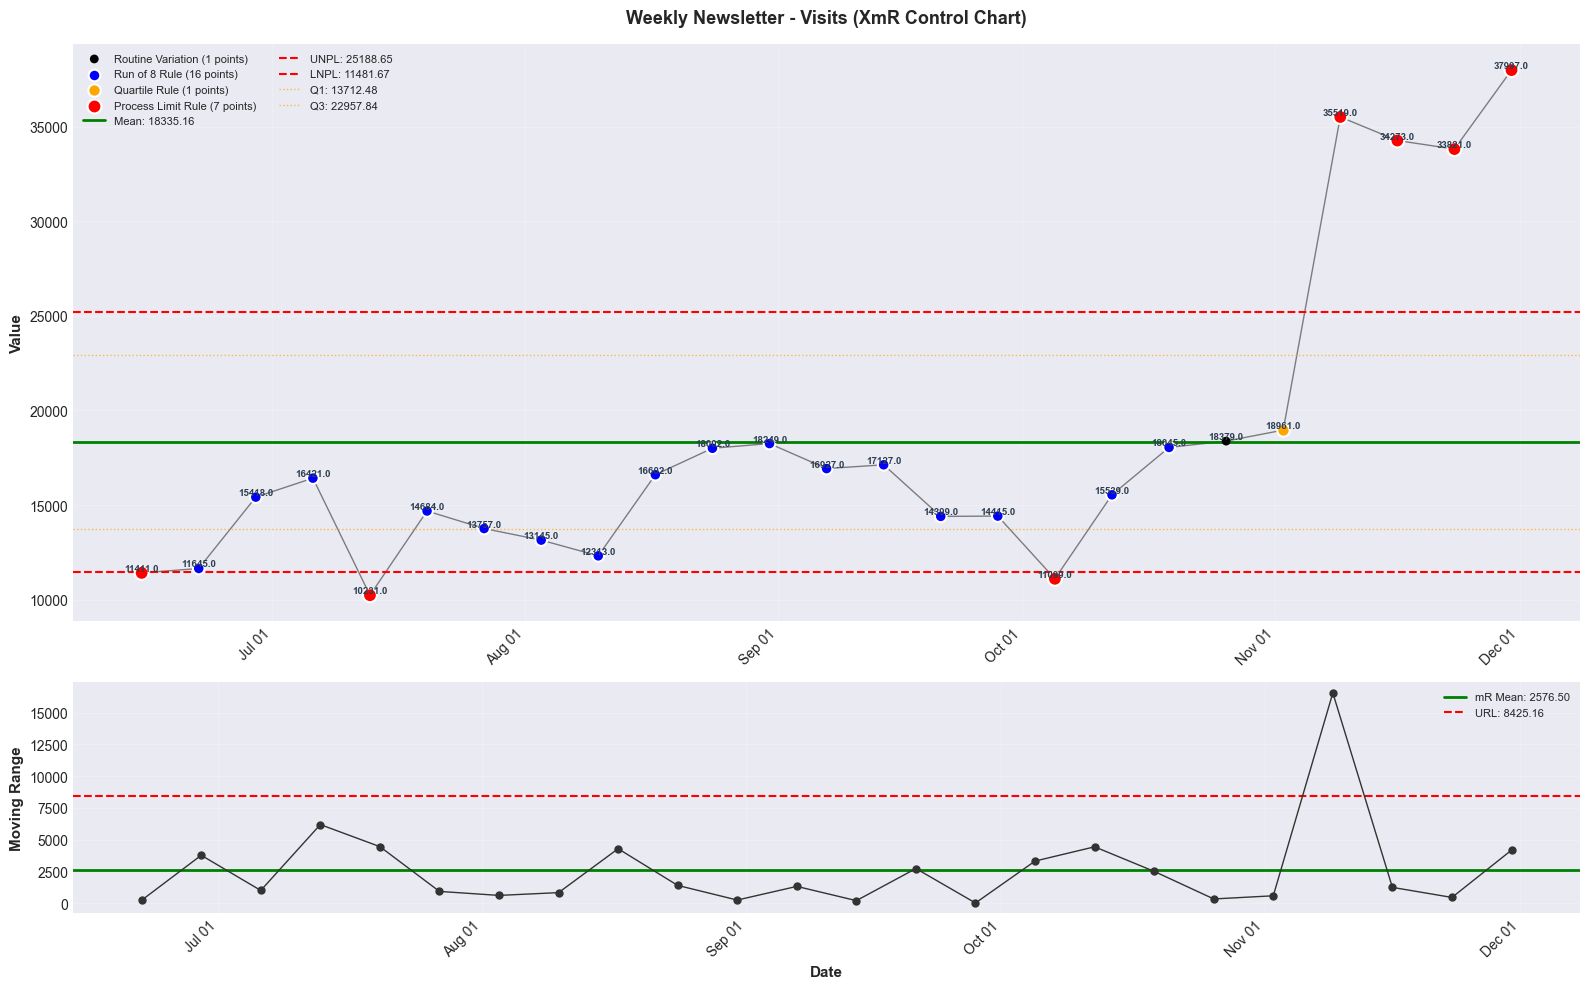

In [20]:
print("\n" + "=" * 70)
print("GENERATING WEEKLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Weekly Visits Chart (XmR Control Chart)
plot_xmr_from_csv(
    csv_path='../outputs/newsletter/weekly_newsletter.csv',
    date_col='Date Range',
    value_col='Visits',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_weekly_dir}/weekly_visits.png',
    chart_title='Weekly Newsletter - Visits (XmR Control Chart)'
)

### Generate Weekly Charts - Avg Duration


GENERATING WEEKLY CHARTS - AVG DURATION

✓ Loaded 26 rows from weekly_newsletter.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 25 data points
✓ Chart saved to: ../visualizations/newsletter_weekly/weekly_avg_duration.png

XmR CHART STATISTICS
Mean: 124.52
UNPL: 158.43
LNPL: 90.61
Q1: 101.65, Q3: 147.39
Moving Range Mean: 12.75
URL (mR): 41.68

Rule Violations Detected:
  Rule 1 (Process Limit): 2 points
  Rule 2 (Quartile): 7 points
  Rule 3 (Runs of 8): 19 points
  Routine Variation: 4 points



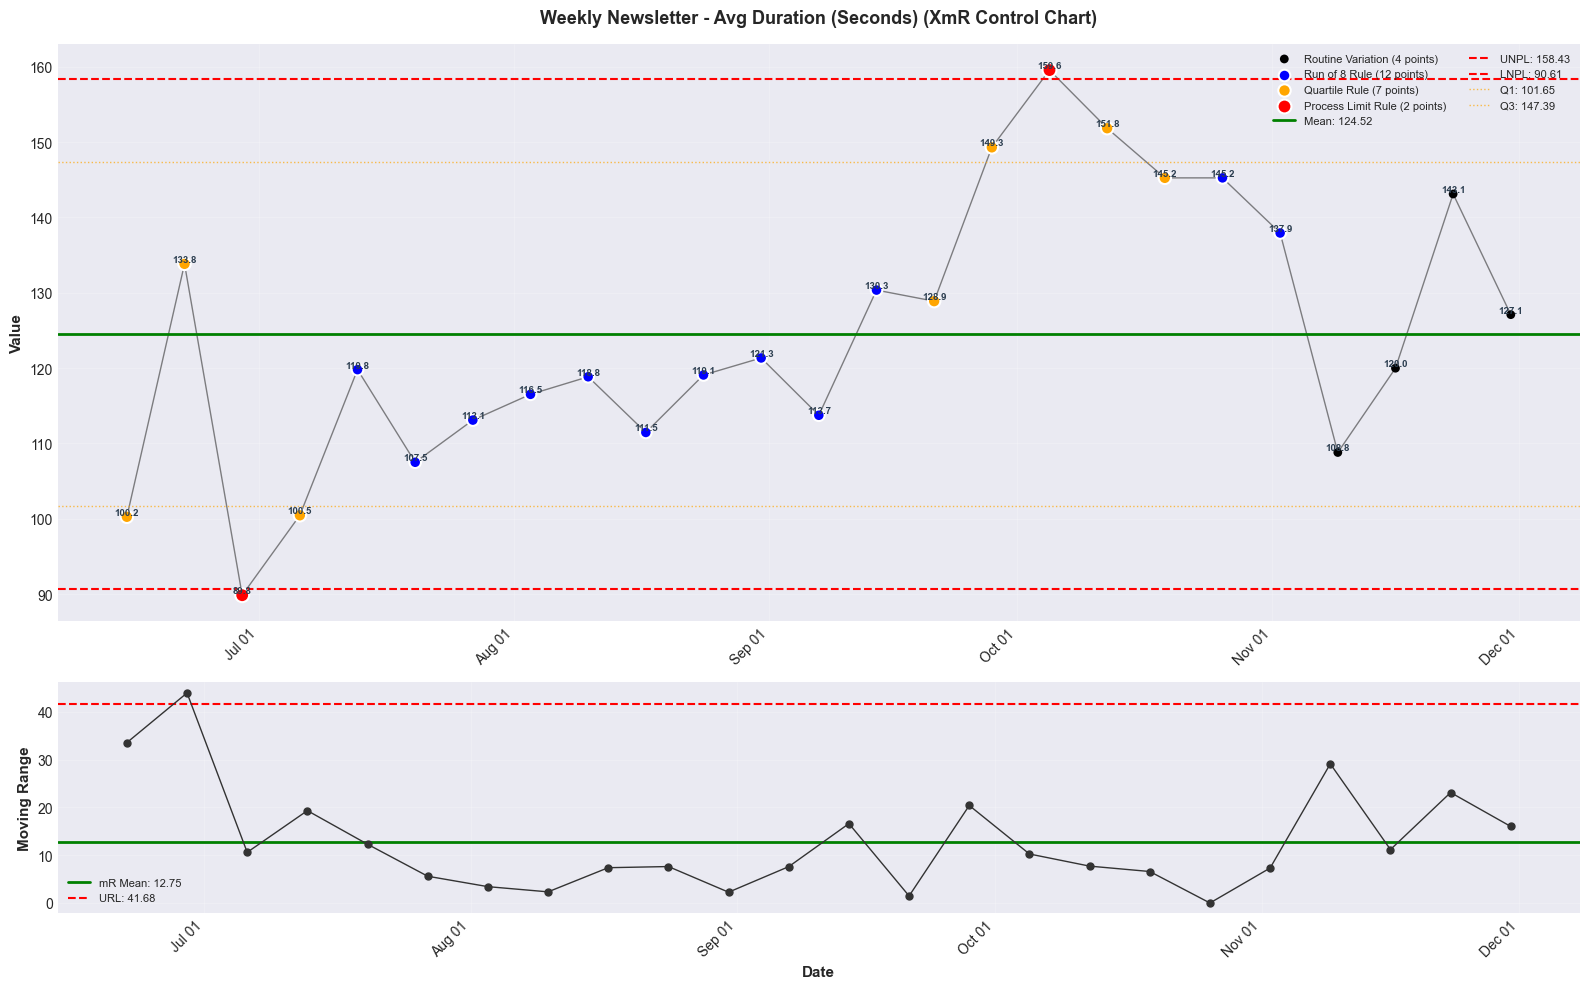

In [21]:
print("\n" + "=" * 70)
print("GENERATING WEEKLY CHARTS - AVG DURATION")
print("=" * 70 + "\n")

# Weekly Avg Duration Chart (XmR Control Chart)
plot_xmr_from_csv(
    csv_path='../outputs/newsletter/weekly_newsletter.csv',
    date_col='Date Range',
    value_col='Avg Duration',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_weekly_dir}/weekly_avg_duration.png',
    chart_title='Weekly Newsletter - Avg Duration (Seconds) (XmR Control Chart)'
)

### Generate Weekly Charts - Bounce Rate


GENERATING WEEKLY CHARTS - BOUNCE RATE

✓ Loaded 26 rows from weekly_newsletter.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 25 data points
✓ Chart saved to: ../visualizations/newsletter_weekly/weekly_bounce_rate.png

XmR CHART STATISTICS
Mean: 90.82
UNPL: 92.18
LNPL: 89.46
Q1: 89.90, Q3: 91.74
Moving Range Mean: 0.51
URL (mR): 1.67

Rule Violations Detected:
  Rule 1 (Process Limit): 1 points
  Rule 2 (Quartile): 0 points
  Rule 3 (Runs of 8): 0 points
  Routine Variation: 24 points



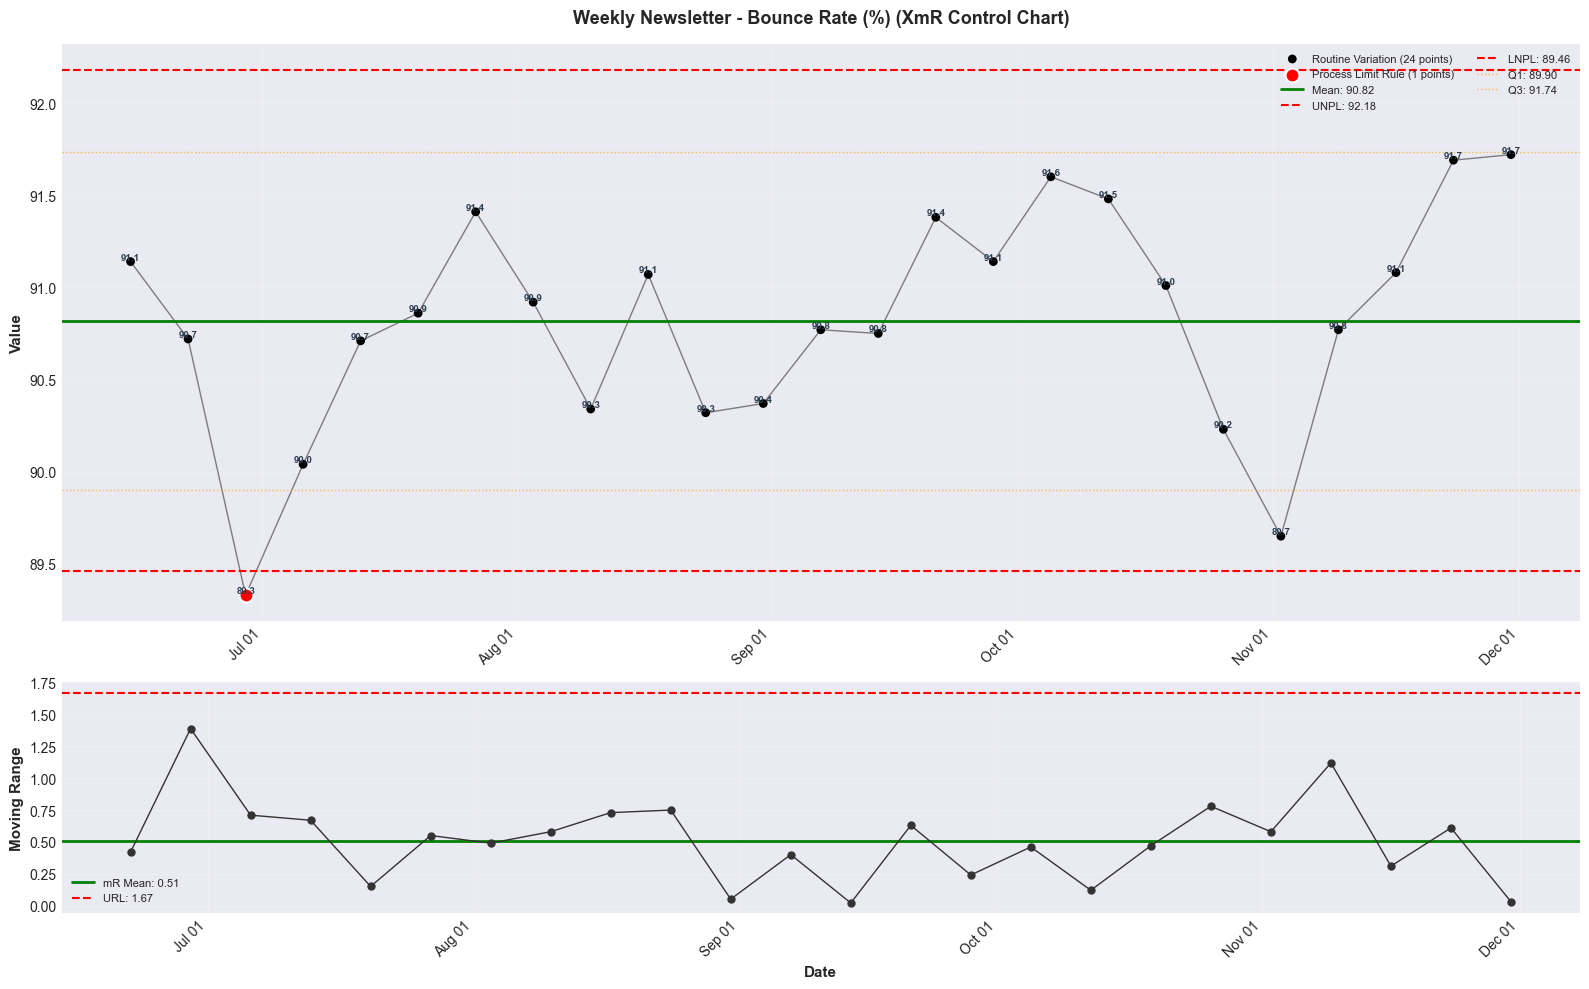

In [22]:
print("\n" + "=" * 70)
print("GENERATING WEEKLY CHARTS - BOUNCE RATE")
print("=" * 70 + "\n")

# Weekly Bounce Rate Chart (XmR Control Chart)
plot_xmr_from_csv(
    csv_path='../outputs/newsletter/weekly_newsletter.csv',
    date_col='Date Range',
    value_col='Bounce Rate',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_weekly_dir}/weekly_bounce_rate.png',
    chart_title='Weekly Newsletter - Bounce Rate (%) (XmR Control Chart)'
)

### Generate Monthly Charts - Visits


GENERATING MONTHLY CHARTS - VISITS

✓ Loaded 7 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 6 complete months
✓ Target line added: 120000.00
✓ Chart saved to: ../visualizations/newsletter_monthly/monthly_visits.png

MONTHLY PERFORMANCE SUMMARY: Visits
Total Complete Months Analyzed: 6
Latest Complete Month: November 2025
Latest Month Value: 130054.00
Target: 120000.00
Gap to Target: +10054.00

Month-over-Month Changes:
  Latest MoM Change: +90.34%
  Average MoM Change: 49.92%

Best Month: Nov 2025 (130054.00)
Worst Month: Jun 2025 (25495.00)



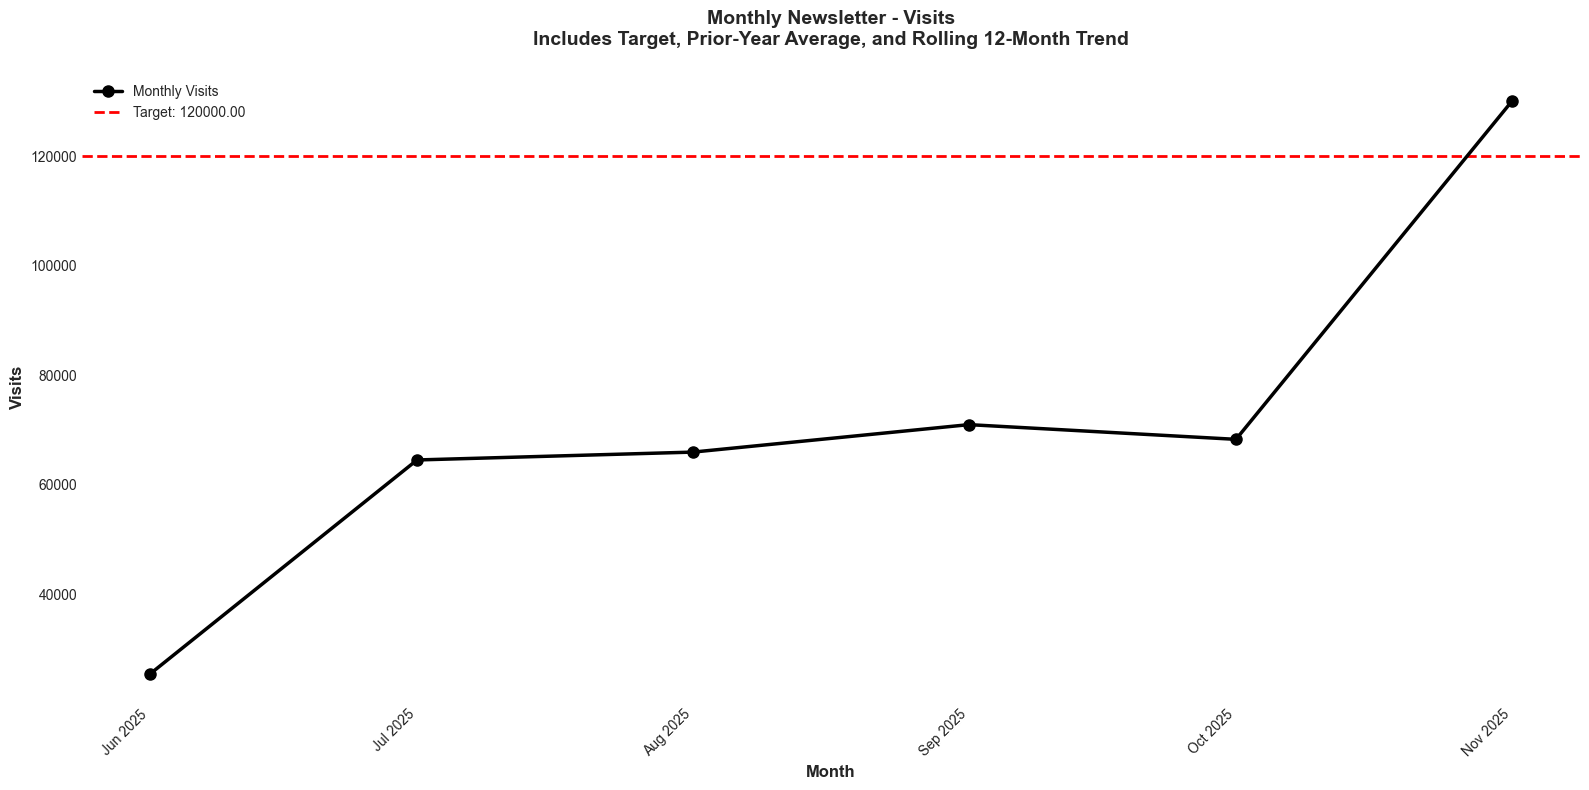

In [23]:
print("\n" + "=" * 70)
print("GENERATING MONTHLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Monthly Visits Chart
create_monthly_chart(
    csv_path='../outputs/newsletter/monthly_newsletter.csv',
    date_col='Month',
    metric_col='Visits',
    target_value=monthly_visits_target,
    output_path=f'{viz_monthly_dir}/monthly_visits.png',
    chart_title='Monthly Newsletter - Visits',
    metric_name='Visits',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Monthly Charts - Avg Duration


GENERATING MONTHLY CHARTS - AVG DURATION

✓ Loaded 7 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 6 complete months
✓ Target line added: 150.00
✓ Chart saved to: ../visualizations/newsletter_monthly/monthly_avg_duration.png

MONTHLY PERFORMANCE SUMMARY: Avg Duration (Seconds)
Total Complete Months Analyzed: 6
Latest Complete Month: November 2025
Latest Month Value: 129.72
Target: 150.00
Gap to Target: -20.28

Month-over-Month Changes:
  Latest MoM Change: -14.05%
  Average MoM Change: 2.73%

Best Month: Oct 2025 (150.92)
Worst Month: Jul 2025 (106.06)



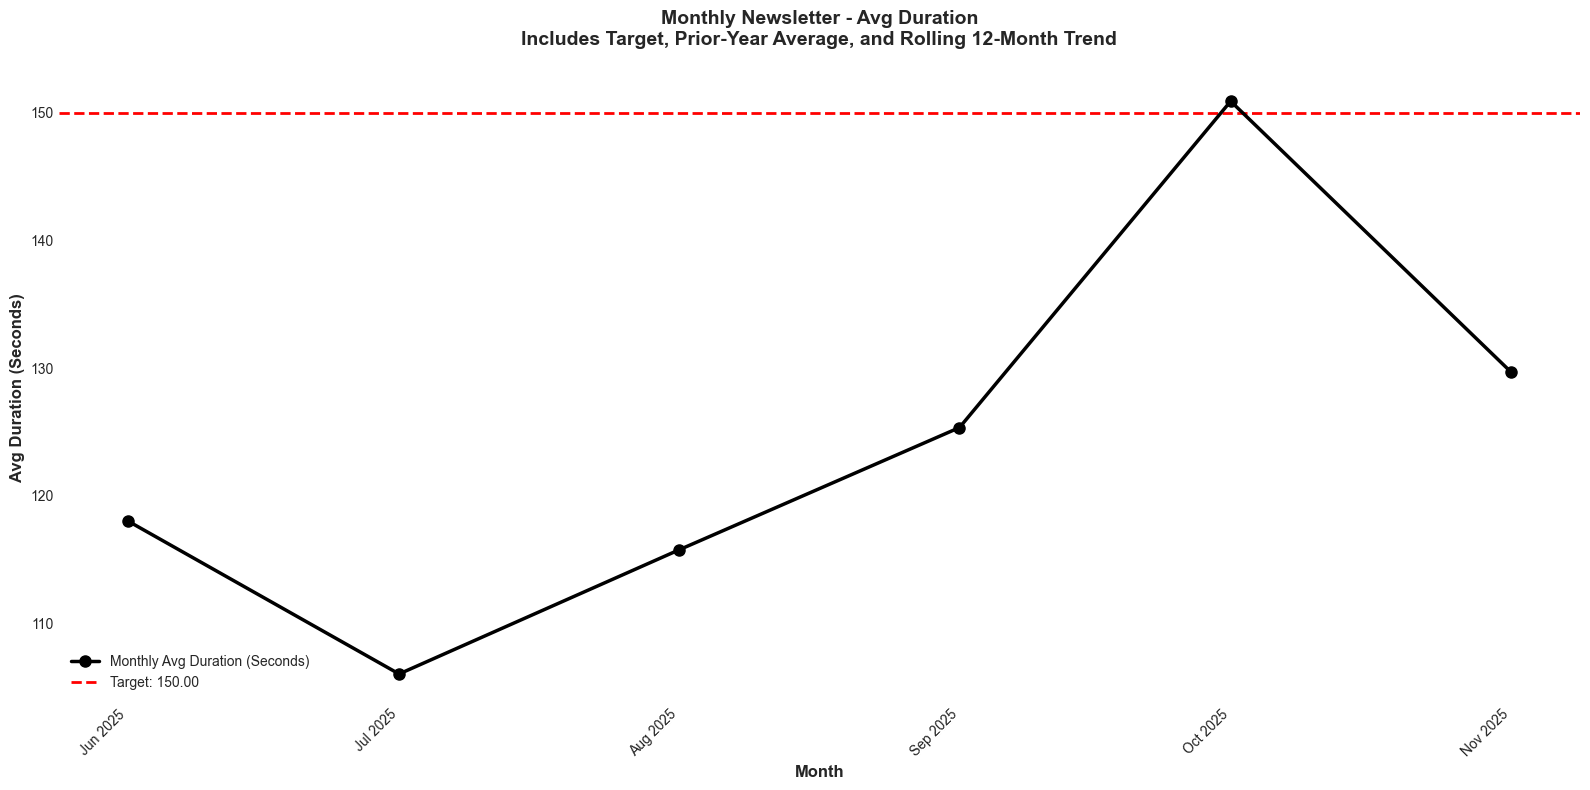

In [24]:
print("\n" + "=" * 70)
print("GENERATING MONTHLY CHARTS - AVG DURATION")
print("=" * 70 + "\n")

# Monthly Avg Duration Chart
create_monthly_chart(
    csv_path='../outputs/newsletter/monthly_newsletter.csv',
    date_col='Month',
    metric_col='Avg Duration',
    target_value=monthly_duration_target,
    output_path=f'{viz_monthly_dir}/monthly_avg_duration.png',
    chart_title='Monthly Newsletter - Avg Duration',
    metric_name='Avg Duration (Seconds)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Monthly Charts - Bounce Rate


GENERATING MONTHLY CHARTS - BOUNCE RATE

✓ Loaded 7 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 6 complete months
✓ Target line added: nan
✓ Chart saved to: ../visualizations/newsletter_monthly/monthly_bounce_rate.png

MONTHLY PERFORMANCE SUMMARY: Bounce Rate (%)
Total Complete Months Analyzed: 6
Latest Complete Month: November 2025
Latest Month Value: 90.81
Target: nan
Gap to Target: +nan

Month-over-Month Changes:
  Latest MoM Change: -0.26%
  Average MoM Change: 0.02%

Best Month: Oct 2025 (91.05)
Worst Month: Jul 2025 (90.49)



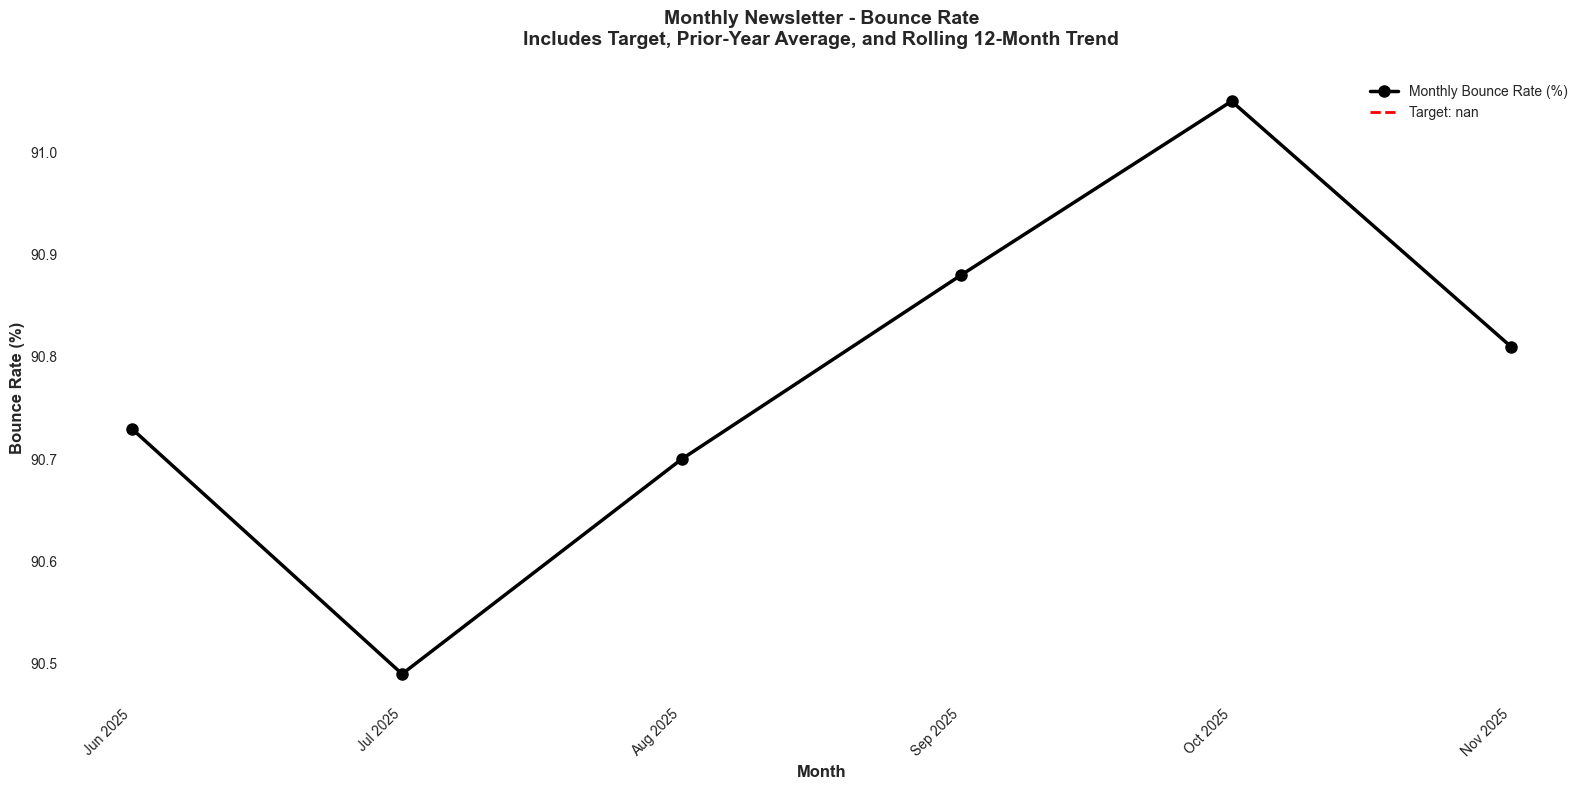

In [25]:
print("\n" + "=" * 70)
print("GENERATING MONTHLY CHARTS - BOUNCE RATE")
print("=" * 70 + "\n")

# Monthly Bounce Rate Chart
create_monthly_chart(
    csv_path='../outputs/newsletter/monthly_newsletter.csv',
    date_col='Month',
    metric_col='Bounce Rate',
    target_value=monthly_bounce_target,
    output_path=f'{viz_monthly_dir}/monthly_bounce_rate.png',
    chart_title='Monthly Newsletter - Bounce Rate',
    metric_name='Bounce Rate (%)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Quarterly Charts - Visits


GENERATING QUARTERLY CHARTS - VISITS

✓ Loaded 3 quarterly records
✓ Visualizing 3 quarters
✓ Target line added: 240000.00
✓ Chart saved to: ../visualizations/newsletter_quarterly/quarterly_visits.png

QUARTERLY PERFORMANCE SUMMARY: Visits
Total Quarters Analyzed: 3
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/08/2025
Latest Quarter Value: 241432.00
Target: 240000.00
Gap to Target: +1432.00

Latest QoQ Change: +19.77%

Best Quarter: 2025Q4 (241432.00)
Worst Quarter: 2025Q2 (25495.00)



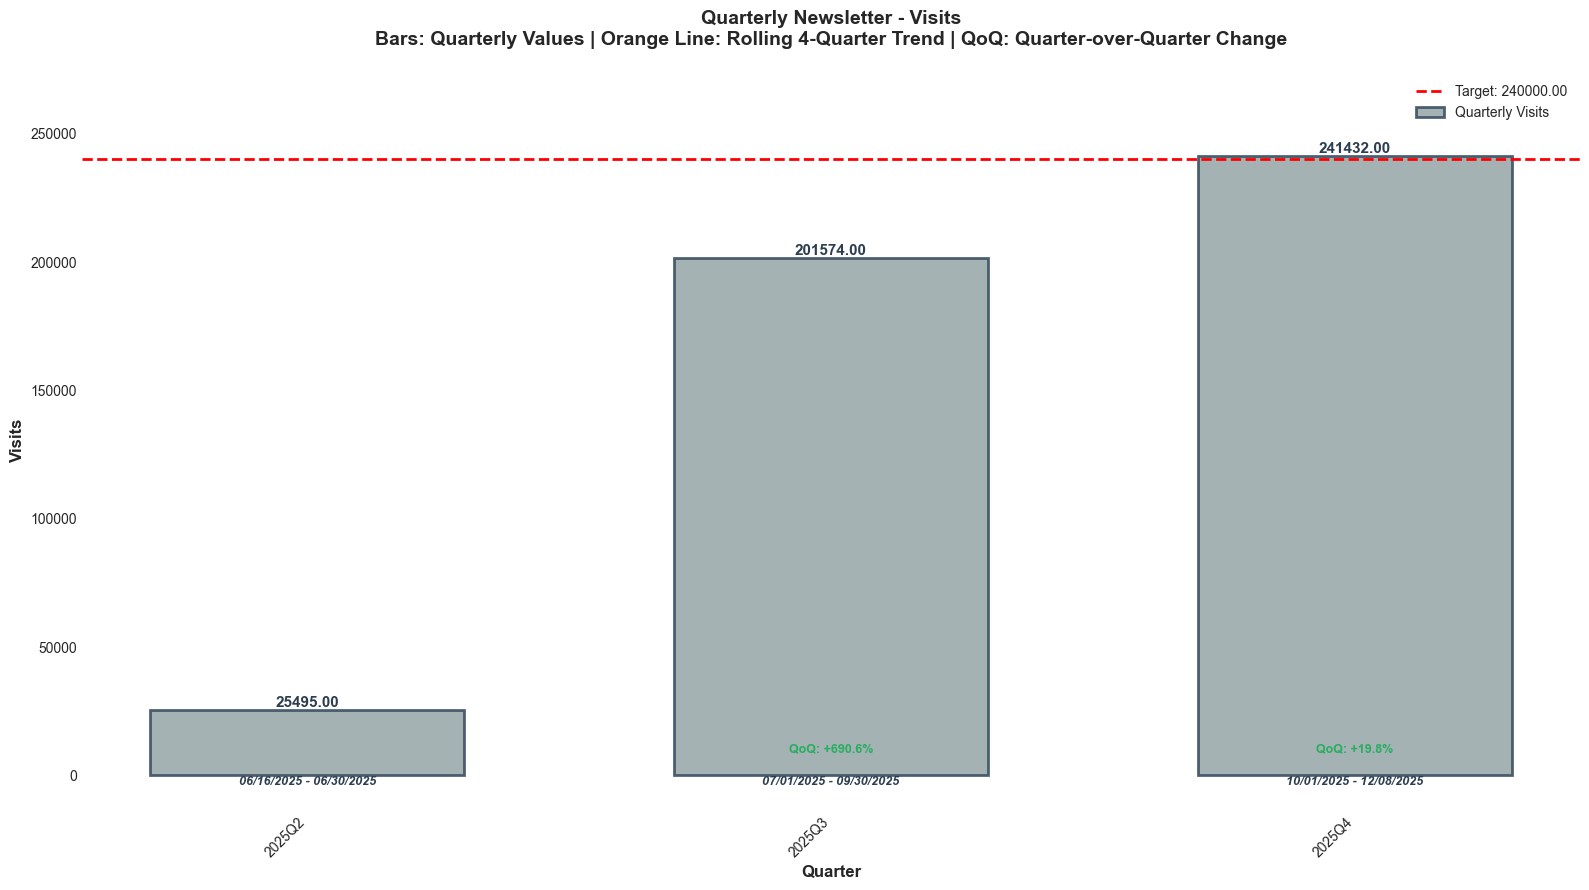

In [26]:
print("\n" + "=" * 70)
print("GENERATING QUARTERLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Quarterly Visits Chart
create_quarterly_chart(
    csv_path='../outputs/newsletter/quarterly_newsletter.csv',
    metric_col='Visits',
    target_value=quarterly_visits_target,
    output_path=f'{viz_quarterly_dir}/quarterly_visits.png',
    chart_title='Quarterly Newsletter - Visits',
    metric_name='Visits'
)

### Generate Quarterly Charts - Avg Duration


GENERATING QUARTERLY CHARTS - AVG DURATION

✓ Loaded 3 quarterly records
✓ Visualizing 3 quarters
✓ Target line added: 150.00
✓ Chart saved to: ../visualizations/newsletter_quarterly/quarterly_avg_duration.png

QUARTERLY PERFORMANCE SUMMARY: Avg Duration (Seconds)
Total Quarters Analyzed: 3
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/08/2025
Latest Quarter Value: 138.50
Target: 150.00
Gap to Target: -11.50

Latest QoQ Change: +19.70%

Best Quarter: 2025Q4 (138.50)
Worst Quarter: 2025Q3 (115.71)



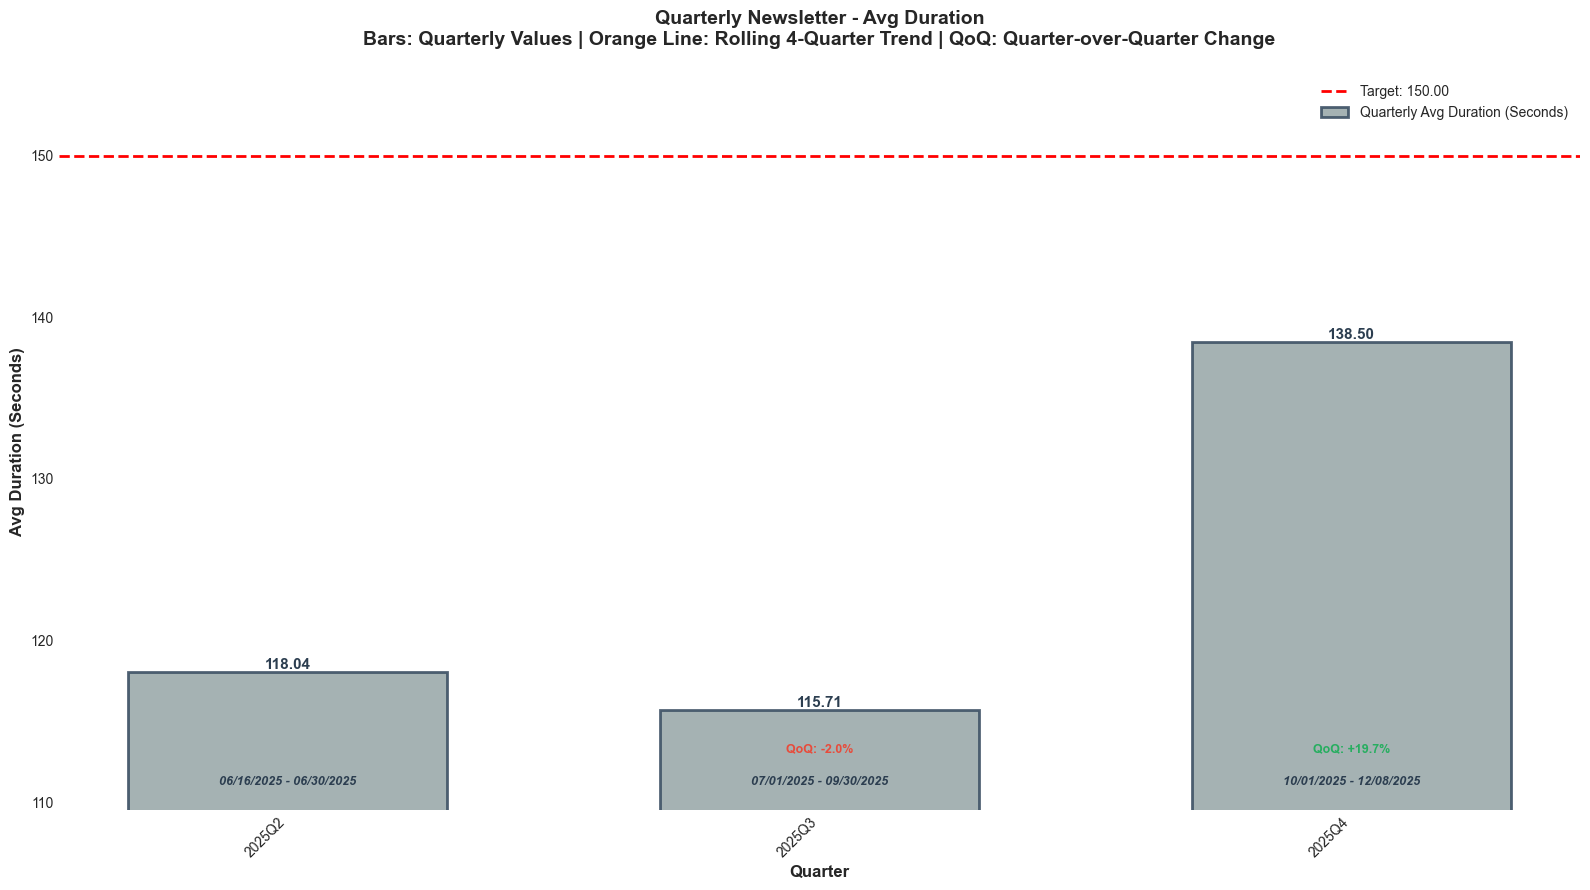

In [27]:
print("\n" + "=" * 70)
print("GENERATING QUARTERLY CHARTS - AVG DURATION")
print("=" * 70 + "\n")

# Quarterly Avg Duration Chart
create_quarterly_chart(
    csv_path='../outputs/newsletter/quarterly_newsletter.csv',
    metric_col='Avg Duration',
    target_value=quarterly_duration_target,
    output_path=f'{viz_quarterly_dir}/quarterly_avg_duration.png',
    chart_title='Quarterly Newsletter - Avg Duration',
    metric_name='Avg Duration (Seconds)'
)

### Generate Quarterly Charts - Bounce Rate


GENERATING QUARTERLY CHARTS - BOUNCE RATE

✓ Loaded 3 quarterly records
✓ Visualizing 3 quarters
✓ Target line added: nan
✓ Chart saved to: ../visualizations/newsletter_quarterly/quarterly_bounce_rate.png

QUARTERLY PERFORMANCE SUMMARY: Bounce Rate (%)
Total Quarters Analyzed: 3
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/08/2025
Latest Quarter Value: 91.03
Target: nan
Gap to Target: +nan

Latest QoQ Change: +0.37%

Best Quarter: 2025Q4 (91.03)
Worst Quarter: 2025Q3 (90.69)



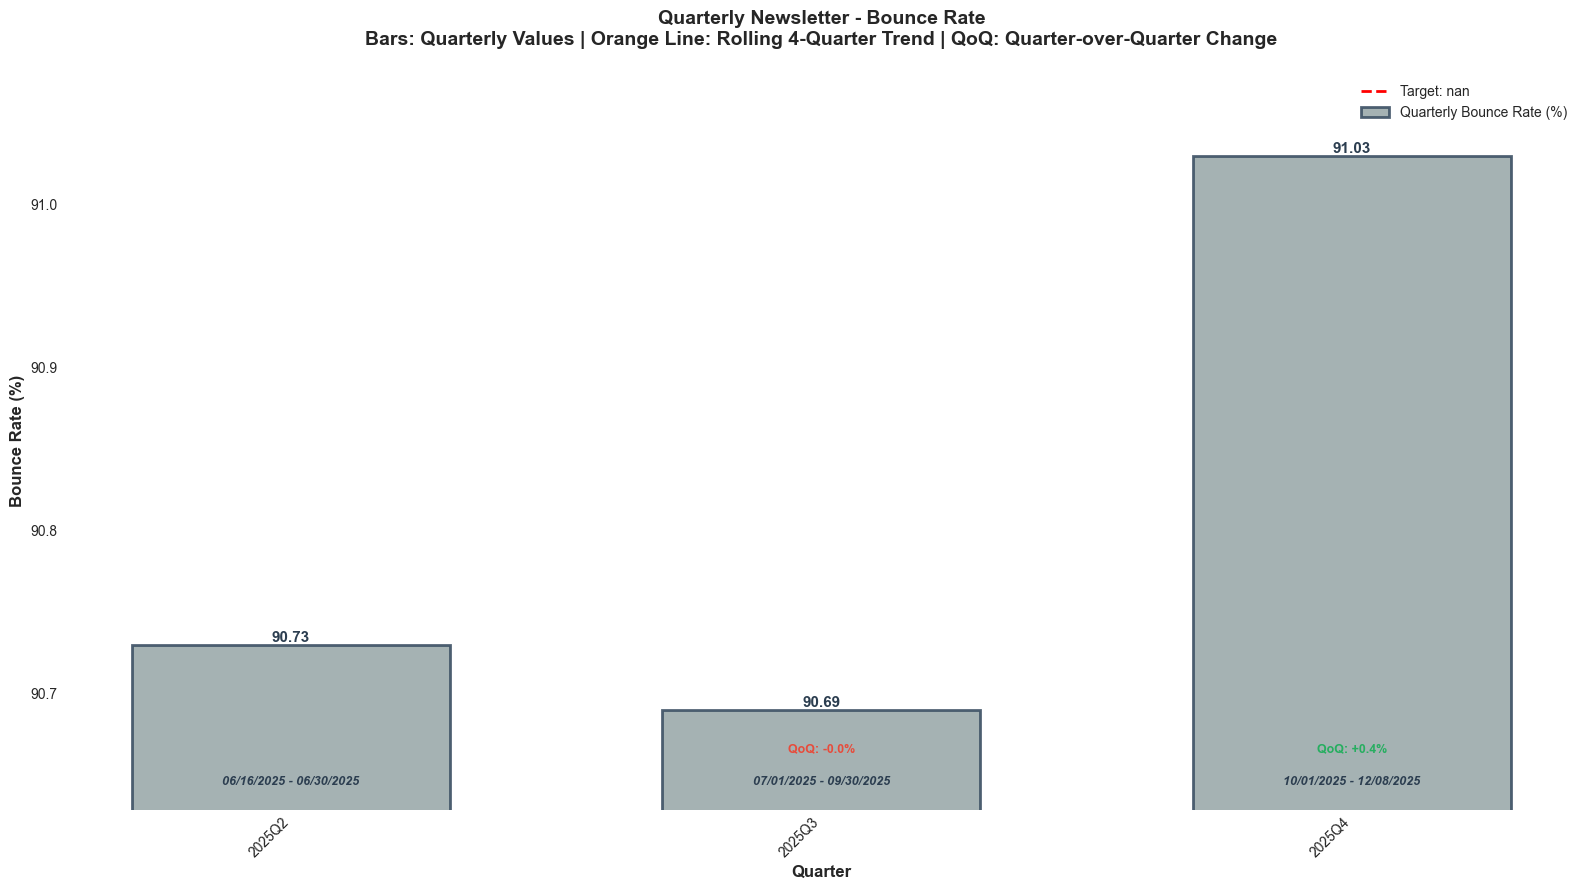

In [28]:
print("\n" + "=" * 70)
print("GENERATING QUARTERLY CHARTS - BOUNCE RATE")
print("=" * 70 + "\n")

# Quarterly Bounce Rate Chart
create_quarterly_chart(
    csv_path='../outputs/newsletter/quarterly_newsletter.csv',
    metric_col='Bounce Rate',
    target_value=quarterly_bounce_target,
    output_path=f'{viz_quarterly_dir}/quarterly_bounce_rate.png',
    chart_title='Quarterly Newsletter - Bounce Rate',
    metric_name='Bounce Rate (%)'
)

### Generate Annual Charts - Visits


GENERATING ANNUAL CHARTS - VISITS

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 300000.00
✓ Chart saved to: ../visualizations/newsletter_annual/annual_visits.png

ANNUAL PERFORMANCE SUMMARY: Visits
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 468501.00
Date Range: 06/16/2025 - 12/08/2025
Target: 300000.00
Gap to Target: +168501.00

Best Year: 2025 (468501.00)
Worst Year: 2025 (468501.00)



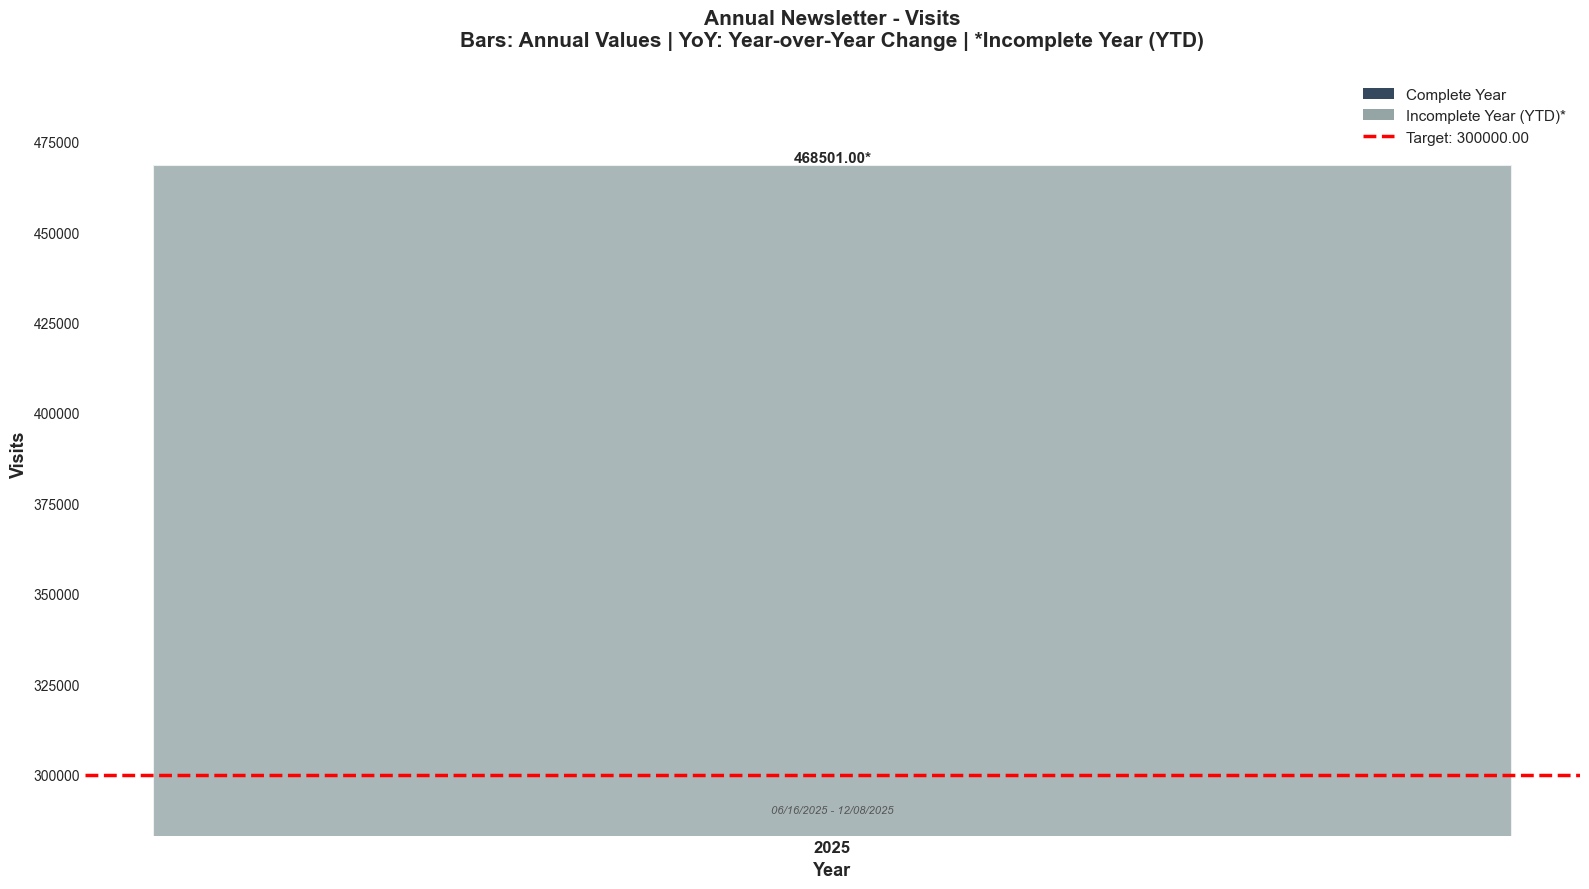

In [29]:
print("\n" + "=" * 70)
print("GENERATING ANNUAL CHARTS - VISITS")
print("=" * 70 + "\n")

# Annual Visits Chart
create_annual_chart(
    csv_path='../outputs/newsletter/annual_newsletter.csv',
    metric_col='Visits',
    target_value=annual_visits_target,
    output_path=f'{viz_annual_dir}/annual_visits.png',
    chart_title='Annual Newsletter - Visits',
    metric_name='Visits'
)

### Generate Annual Charts - Avg Duration


GENERATING ANNUAL CHARTS - AVG DURATION

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 170.00
✓ Chart saved to: ../visualizations/newsletter_annual/annual_avg_duration.png

ANNUAL PERFORMANCE SUMMARY: Avg Duration (Seconds)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 124.96
Date Range: 06/16/2025 - 12/08/2025
Target: 170.00
Gap to Target: -45.04

Best Year: 2025 (124.96)
Worst Year: 2025 (124.96)



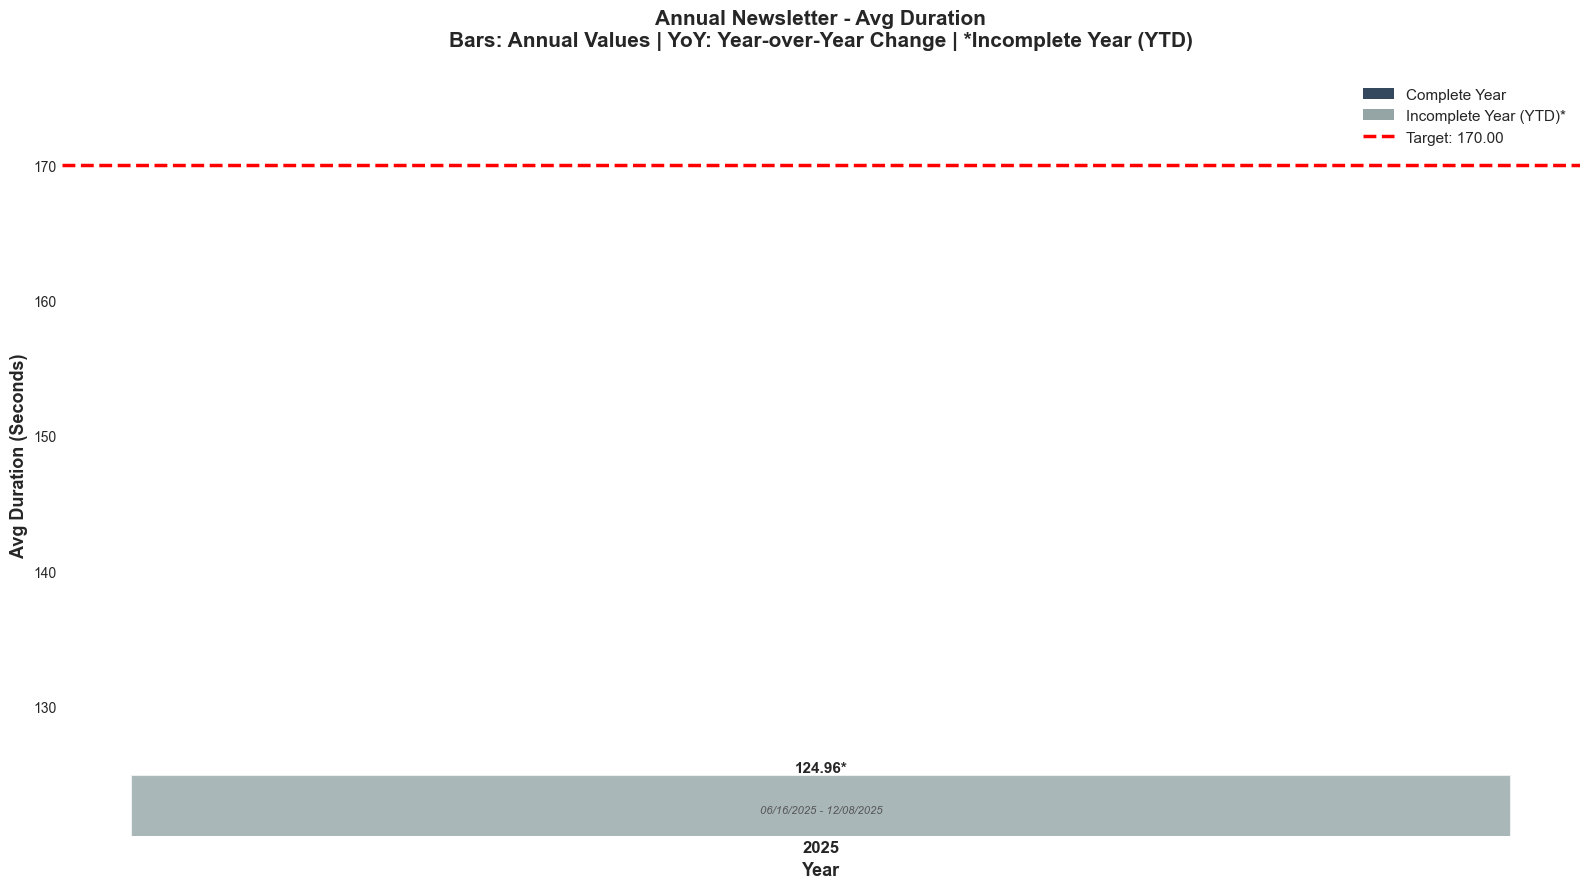

In [30]:
print("\n" + "=" * 70)
print("GENERATING ANNUAL CHARTS - AVG DURATION")
print("=" * 70 + "\n")

# Annual Avg Duration Chart
create_annual_chart(
    csv_path='../outputs/newsletter/annual_newsletter.csv',
    metric_col='Avg Duration',
    target_value=annual_duration_target,
    output_path=f'{viz_annual_dir}/annual_avg_duration.png',
    chart_title='Annual Newsletter - Avg Duration',
    metric_name='Avg Duration (Seconds)'
)

### Generate Annual Charts - Bounce Rate


GENERATING ANNUAL CHARTS - BOUNCE RATE

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: nan
✓ Chart saved to: ../visualizations/newsletter_annual/annual_bounce_rate.png

ANNUAL PERFORMANCE SUMMARY: Bounce Rate (%)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 90.82
Date Range: 06/16/2025 - 12/08/2025
Target: nan
Gap to Target: +nan

Best Year: 2025 (90.82)
Worst Year: 2025 (90.82)



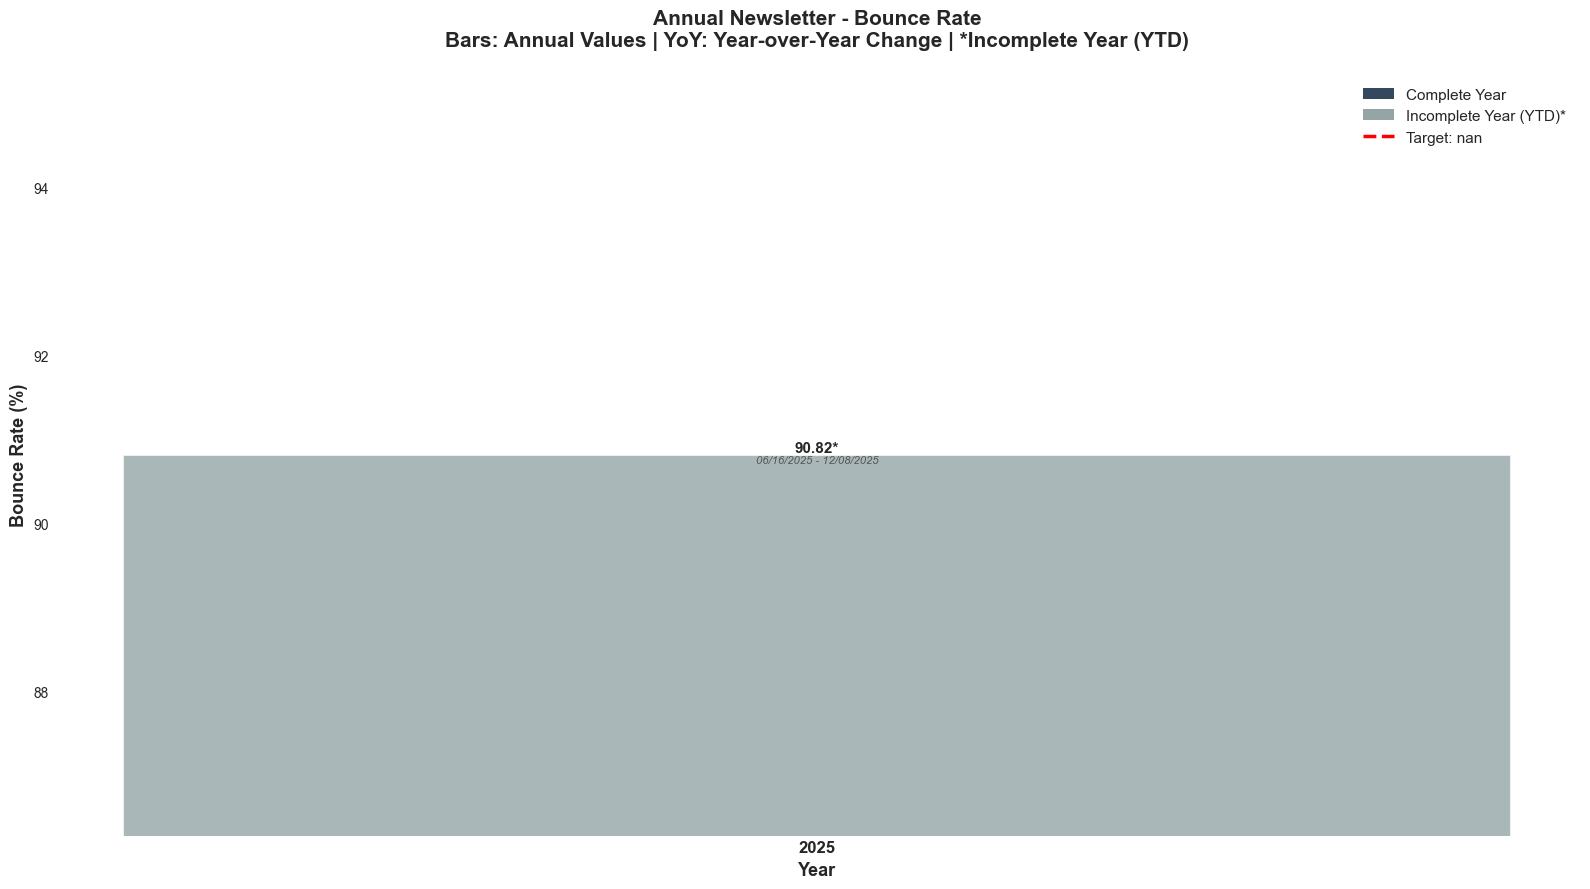

In [31]:
print("\n" + "=" * 70)
print("GENERATING ANNUAL CHARTS - BOUNCE RATE")
print("=" * 70 + "\n")

# Annual Bounce Rate Chart
create_annual_chart(
    csv_path='../outputs/newsletter/annual_newsletter.csv',
    metric_col='Bounce Rate',
    target_value=annual_bounce_target,
    output_path=f'{viz_annual_dir}/annual_bounce_rate.png',
    chart_title='Annual Newsletter - Bounce Rate',
    metric_name='Bounce Rate (%)'
)

### Visualization Summary

In [32]:
print("\n" + "=" * 70)
print("VISUALIZATION GENERATION COMPLETE")
print("=" * 70)

# Count generated files
weekly_charts = len([f for f in os.listdir(viz_weekly_dir) if f.endswith('.png')])
monthly_charts = len([f for f in os.listdir(viz_monthly_dir) if f.endswith('.png')])
quarterly_charts = len([f for f in os.listdir(viz_quarterly_dir) if f.endswith('.png')])
annual_charts = len([f for f in os.listdir(viz_annual_dir) if f.endswith('.png')])

total_charts = weekly_charts + monthly_charts + quarterly_charts + annual_charts

print(f"\n📊 Charts Generated Summary:")
print(f"  Weekly Charts: {weekly_charts} (XmR Control Charts)")
print(f"  Monthly Charts: {monthly_charts} (Trend + Target)")
print(f"  Quarterly Charts: {quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual Charts: {annual_charts} (Bars + Trend + Target)")
print(f"\n  Total Charts Generated: {total_charts}")

print(f"\n📁 Visualization Directories:")
print(f"  Weekly: {viz_weekly_dir}")
print(f"  Monthly: {viz_monthly_dir}")
print(f"  Quarterly: {viz_quarterly_dir}")
print(f"  Annual: {viz_annual_dir}")

print("\n" + "=" * 70)
print("✓ All newsletter charts generated successfully!")
print("=" * 70 + "\n")


VISUALIZATION GENERATION COMPLETE

📊 Charts Generated Summary:
  Weekly Charts: 3 (XmR Control Charts)
  Monthly Charts: 3 (Trend + Target)
  Quarterly Charts: 3 (Bars + Trend + Target)
  Annual Charts: 3 (Bars + Trend + Target)

  Total Charts Generated: 12

📁 Visualization Directories:
  Weekly: ../visualizations/newsletter_weekly
  Monthly: ../visualizations/newsletter_monthly
  Quarterly: ../visualizations/newsletter_quarterly
  Annual: ../visualizations/newsletter_annual

✓ All newsletter charts generated successfully!



### List All Generated Charts

In [33]:
# Display all generated chart files
print("\n" + "=" * 70)
print("GENERATED CHART FILES")
print("=" * 70 + "\n")

print("WEEKLY CHARTS (XmR Control Charts):")
print("-" * 70)
for file in sorted(os.listdir(viz_weekly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_weekly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nMONTHLY CHARTS (Trend + Target + MoM%):")
print("-" * 70)
for file in sorted(os.listdir(viz_monthly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_monthly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nQUARTERLY CHARTS (Bars + Trend + Target + QoQ%):")
print("-" * 70)
for file in sorted(os.listdir(viz_quarterly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_quarterly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nANNUAL CHARTS (Bars + Trend + Target + YoY%):")
print("-" * 70)
for file in sorted(os.listdir(viz_annual_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_annual_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\n" + "=" * 70)


GENERATED CHART FILES

WEEKLY CHARTS (XmR Control Charts):
----------------------------------------------------------------------
  • weekly_avg_duration.png                  (523.6 KB)
  • weekly_bounce_rate.png                   (507.8 KB)
  • weekly_visits.png                        (520.5 KB)

MONTHLY CHARTS (Trend + Target + MoM%):
----------------------------------------------------------------------
  • monthly_avg_duration.png                 (274.9 KB)
  • monthly_bounce_rate.png                  (277.3 KB)
  • monthly_visits.png                       (226.5 KB)

QUARTERLY CHARTS (Bars + Trend + Target + QoQ%):
----------------------------------------------------------------------
  • quarterly_avg_duration.png               (205.2 KB)
  • quarterly_bounce_rate.png                (197.6 KB)
  • quarterly_visits.png                     (203.8 KB)

ANNUAL CHARTS (Bars + Trend + Target + YoY%):
----------------------------------------------------------------------
  • annual_avg

#

## CUSTOM DATE RANGE ANALYSIS

### Load Custom Date Range Parameters

In [34]:
# Load analysis reference dates from CSV
ref_dates_path = '../analysis_ref_date.csv'

# Check if file exists
if not os.path.exists(ref_dates_path):
    print(f"❌ Error: File not found at {ref_dates_path}")
    custom_start = None
    custom_end = None
else:
    # Load reference dates
    ref_dates = pd.read_csv(ref_dates_path, header=None)
    
    # Parse custom date range
    custom_start = None
    custom_end = None
    
    for idx, row in ref_dates.iterrows():
        if row[0] == 'Custom Start Date':
            try:
                custom_start = pd.to_datetime(row[1])
            except:
                custom_start = None
        elif row[0] == 'Custom End Date':
            try:
                custom_end = pd.to_datetime(row[1])
            except:
                custom_end = None
    
    print(f"Custom Date Range:")
    print(f"  Start: {custom_start if custom_start else 'Not specified'}")
    print(f"  End: {custom_end if custom_end else 'Not specified'}")
    
    if custom_start and custom_end:
        date_range_days = (custom_end - custom_start).days + 1
        print(f"  Duration: {date_range_days} days")
    else:
        print("\n⚠️ Custom date range not properly specified in analysis_ref_date.csv")

Custom Date Range:
  Start: 2025-11-01 00:00:00
  End: 2025-11-28 00:00:00
  Duration: 28 days


### Generate Custom Date Range Aggregated Data

In [35]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE AGGREGATION (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    # Calculate previous period dates - shift back by ONE MONTH, keeping same day-of-month
    from dateutil.relativedelta import relativedelta
    
    prev_start = custom_start - relativedelta(months=1)
    prev_end = custom_end - relativedelta(months=1)
    
    # Calculate duration for display
    date_range_duration = (custom_end - custom_start).days + 1
    
    print(f"Current Period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')} ({date_range_duration} days)")
    print(f"Previous Period: {prev_start.strftime('%m/%d/%Y')} - {prev_end.strftime('%m/%d/%Y')} ({date_range_duration} days)\n")
    
    # Work with original data with datetime
    df_custom_prep = df.copy()
    df_custom_prep['Date'] = pd.to_datetime(df_custom_prep['Date'])
    
    # Filter data for CURRENT custom date range
    df_custom_filtered = df_custom_prep[
        (df_custom_prep['Date'] >= custom_start) & 
        (df_custom_prep['Date'] <= custom_end)
    ].copy()
    
    # Filter data for PREVIOUS custom date range
    df_prev_filtered = df_custom_prep[
        (df_custom_prep['Date'] >= prev_start) & 
        (df_custom_prep['Date'] <= prev_end)
    ].copy()
    
    # Create empty list to store rows
    custom_rows = []
    
    # Process CURRENT period
    if len(df_custom_filtered) > 0:
        # Calculate the actual start and end dates from filtered data
        actual_start = df_custom_filtered['Date'].min()
        actual_end = df_custom_filtered['Date'].max()
        
        # Aggregate ALL the filtered data (sum pageviews/visits, mean for duration/bounce rate)
        total_pageviews = df_custom_filtered['Pageviews'].sum()
        total_visits = df_custom_filtered['Visits'].sum()
        avg_duration = df_custom_filtered['Avg Duration'].mean()
        avg_bounce_rate = df_custom_filtered['Bounce Rate'].mean()
        
        current_row = {
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Pageviews': int(total_pageviews),
            'Visits': int(total_visits),
            'Avg Duration': round(avg_duration, 2),
            'Bounce Rate': f"{round(avg_bounce_rate * 100, 2)}%"
        }
        custom_rows.append(current_row)
        
        print(f"✅ Current period data found: {len(df_custom_filtered)} hourly records")
        print(f"   Total Pageviews: {total_pageviews:,}")
        print(f"   Total Visits: {total_visits:,}")
        
    else:
        print(f"⚠️ No data for current period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
    
    # Process PREVIOUS period
    if len(df_prev_filtered) > 0:
        # Calculate the actual start and end dates from filtered data
        actual_start = df_prev_filtered['Date'].min()
        actual_end = df_prev_filtered['Date'].max()
        
        # Aggregate ALL the filtered data (sum pageviews/visits, mean for duration/bounce rate)
        total_pageviews = df_prev_filtered['Pageviews'].sum()
        total_visits = df_prev_filtered['Visits'].sum()
        avg_duration = df_prev_filtered['Avg Duration'].mean()
        avg_bounce_rate = df_prev_filtered['Bounce Rate'].mean()
        
        prev_row = {
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Pageviews': int(total_pageviews),
            'Visits': int(total_visits),
            'Avg Duration': round(avg_duration, 2),
            'Bounce Rate': f"{round(avg_bounce_rate * 100, 2)}%"
        }
        custom_rows.append(prev_row)
        
        print(f"✅ Previous period data found: {len(df_prev_filtered)} hourly records")
        print(f"   Total Pageviews: {total_pageviews:,}")
        print(f"   Total Visits: {total_visits:,}")
        
    else:
        print(f"⚠️ No data for previous period: {prev_start.strftime('%m/%d/%Y')} - {prev_end.strftime('%m/%d/%Y')}")
    
    # Create final dataframe
    if len(custom_rows) > 0:
        df_custom = pd.DataFrame(custom_rows)
        
        # Display the results
        print("\n" + "="*70)
        print("Custom Date Range Aggregated Data (with Previous Period):")
        print("="*70)
        display(df_custom)
        
    else:
        print("\n⚠️ No data available for either current or previous period")
        df_custom = None
        
else:
    print("❌ Cannot generate custom analysis - dates not properly specified")
    print("   Please check Custom Start Date and Custom End Date in analysis_ref_date.csv")
    df_custom = None

print("\n" + "="*70)


CUSTOM DATE RANGE AGGREGATION (WITH PREVIOUS PERIOD)

Current Period: 11/01/2025 - 11/28/2025 (28 days)
Previous Period: 10/01/2025 - 10/28/2025 (28 days)

✅ Current period data found: 672 hourly records
   Total Pageviews: 136,358
   Total Visits: 120,443
✅ Previous period data found: 672 hourly records
   Total Pageviews: 68,243
   Total Visits: 60,443

Custom Date Range Aggregated Data (with Previous Period):


,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate
0,11/01/2025 - 11/28/2025,136358,120443,127.48,90.77%
1,10/01/2025 - 10/28/2025,68243,60443,151.00,91.2%


### Save Custom Date Range Data

In [36]:
if df_custom is not None and len(df_custom) > 0:
    # Save to CSV
    custom_path = os.path.join(output_dir, 'custom_newsletter.csv')
    df_custom.to_csv(custom_path, index=False)
    
    print("\n" + "="*70)
    print("CUSTOM DATE RANGE ANALYSIS - COMPLETE")
    print("="*70)
    
    print(f"\n✅ OUTPUT CREATED:")
    print(f"  - custom_newsletter.csv")
    
    print(f"\n📁 Saved in:")
    print(f"  - {custom_path}")
    
    print(f"\n📊 File Details:")
    print(f"  - Shape: {df_custom.shape[0]} rows × {df_custom.shape[1]} columns")
    print(f"  - Date Range: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
    print(f"  - Duration: {(custom_end - custom_start).days + 1} days")
    
    print(f"\n📈 Columns:")
    print(f"  - Date Range, Pageviews, Visits, Avg Duration, Bounce Rate")
    
    print("\n" + "="*70)
else:
    print("\n⚠️ Custom analysis not saved - no data to save")
    print("   Check date range and data availability")


CUSTOM DATE RANGE ANALYSIS - COMPLETE

✅ OUTPUT CREATED:
  - custom_newsletter.csv

📁 Saved in:
  - ../outputs/newsletter/custom_newsletter.csv

📊 File Details:
  - Shape: 2 rows × 5 columns
  - Date Range: 11/01/2025 - 11/28/2025
  - Duration: 28 days

📈 Columns:
  - Date Range, Pageviews, Visits, Avg Duration, Bounce Rate

